<a href="https://colab.research.google.com/github/katemeinke/DSC-Project-2/blob/main/Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 2: Measuring Stress During Exams

This data contains information about skin conductance recordings where the human stress response is being recorded. The data displays electrodermal activity, heart rate, blood volume pulse, skin surface temperature, inter beat interval, and accelerometer data that was recorded during 3 exam sessions. (midterm 1, midterm 2, and finals) in accordance with the student's grades. The idea is to measure the influence of stress on exam performance. The featured variable would be fluctuations in skin conductance when undergoing a stressful exam experience. The students wore a device called the Empatica E4 wristband while they take their exams. This device recorded skin conductance, heart rate, body temperature, and movement. The dataset contains two female and eight male participants.

citation: @article{PhysioNet-wearable-exam-stress-1.0.0,
  author = {Amin, Md Rafiul and Wickramasuriya, Dilranjan and Faghih, Rose T},
  title = {{A Wearable Exam Stress Dataset for Predicting Cognitive Performance in Real-World Settings}},
  journal = {{PhysioNet}},
  year = {2022},
  month = may,
  note = {Version 1.0.0},
  doi = {10.13026/kvkb-aj90},
  url = {https://doi.org/10.13026/kvkb-aj90}
}

## Research Goals:
main hypothesis: what is the effect of stress on the body?
 1. How do stress-related biometric signals change across 3 exams? (Do students get more stress or learn to handle it better throughout the year?
 2. Do students with higher physiological stress patterns tend to have lower grades?
 3. Which measure appears to vary the most during the exams?

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import os

In [ ]:
# import google drive
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
data_path = '/content/drive/MyDrive/Data/'

In [ ]:
items = os.listdir(data_path)
print(items)

['S8', 'S9', 'S6', 'S5', 'S1', 'S2', 'S10', 'S4', 'S7', 'S3']


In [ ]:
final = data_path+'S1/Final/'
midterm1_s1 = data_path+'S1/Midterm 1/'
midterm2_s1 = data_path+'S1/Midterm 2/'

In [ ]:
final_s2 = data_path+'S2/Final/'
midterm1_s2 = data_path+'S2/Midterm 1/'
midterm2_s2 = data_path+'S2/Midterm 2/'

In [ ]:
final_s3 = data_path+'S3/Final/'
midterm1_s3 = data_path+'S3/Midterm 1/'
midterm2_s3 = data_path+'S3/Midterm 2/'

In [ ]:
os.listdir(final)

['ACC.csv',
 'BVP.csv',
 'EDA.csv',
 'tags.csv',
 'info.txt',
 'IBI.csv',
 'HR.csv',
 'TEMP.csv']

In [ ]:
# open the final file
with open(final+'/info.txt', "r") as f:
    for line in f:
        print(line.strip())

.csv files in this archive are in the following format:
The first row is the initial time of the session expressed as unix timestamp in UTC.
The second row is the sample rate expressed in Hz.

TEMP.csv
Data from temperature sensor expressed degrees on the Celsius (°C) scale.

EDA.csv
Data from the electrodermal activity sensor expressed as microsiemens (μS).

BVP.csv
Data from photoplethysmograph.

ACC.csv
Data from 3-axis accelerometer sensor. The accelerometer is configured to measure acceleration in the range [-2g, 2g]. Therefore the unit in this file is 1/64g.
Data from x, y, and z axis are respectively in first, second, and third column.

IBI.csv
Time between individuals heart beats extracted from the BVP signal.
No sample rate is needed for this file.
The first column is the time (respect to the initial time) of the detected inter-beat interval expressed in seconds (s).
The second column is the duration in seconds (s) of the detected inter-beat interval (i.e., the distance in sec

In [ ]:
# read the file
s1_final_acc= pd.read_csv(final+'/ACC.csv')
s1_final_acc.head()

,1544027337.000000,1544027337.000000,1544027337.000000.1
0,32.0,32.0,32.0
1,-3.0,65.0,6.0
2,-3.0,65.0,6.0
3,-3.0,65.0,6.0
4,-3.0,65.0,6.0


In [ ]:
s1_final_acc.columns = ['x', 'y', 'z']
s1_final_acc.head()

,x,y,z
0,32.0,32.0,32.0
1,-3.0,65.0,6.0
2,-3.0,65.0,6.0
3,-3.0,65.0,6.0
4,-3.0,65.0,6.0


In [ ]:
sampling_freq = s1_final_acc.iloc[0].values
sampling_freq

array([32., 32., 32.])

In [ ]:
acc_s1 = s1_final_acc.iloc[1:].copy().reset_index(drop=True)
acc_s1

,x,y,z
0,-3.0,65.0,6.0
1,-3.0,65.0,6.0
2,-3.0,65.0,6.0
3,-3.0,65.0,6.0
4,-3.0,65.0,6.0
...,...,...,...
748681,-24.0,42.0,42.0
748682,-24.0,42.0,43.0
748683,-25.0,42.0,42.0
748684,-24.0,42.0,44.0


In [ ]:
acc_s1['Time'] = np.round(acc_s1.index / sampling_freq[0], 2)

In [ ]:
acc_s1

,x,y,z,Time
0,-3.0,65.0,6.0,0.00
1,-3.0,65.0,6.0,0.03
2,-3.0,65.0,6.0,0.06
3,-3.0,65.0,6.0,0.09
4,-3.0,65.0,6.0,0.12
...,...,...,...,...
748681,-24.0,42.0,42.0,23396.28
748682,-24.0,42.0,43.0,23396.31
748683,-25.0,42.0,42.0,23396.34
748684,-24.0,42.0,44.0,23396.38


In [ ]:
s1_final_bvp= pd.read_csv(final+'/BVP.csv')
s1_final_bvp.head()

,1544027337.00
0,64.0
1,-0.0
2,-0.0
3,-0.0
4,-0.0


In [ ]:
s1_final_bvp.columns = ['bvp']
bvp_frequency = s1_final_bvp.iloc[0].values

In [ ]:
bvp_s1 = s1_final_bvp.iloc[1:].copy().reset_index(drop=True)
bvp_s1['Time'] = np.round(bvp_s1.index / bvp_frequency[0], 2)
bvp_s1.head()

,bvp,Time
0,-0.0,0.00
1,-0.0,0.02
2,-0.0,0.03
3,-0.0,0.05
4,-0.0,0.06


In [ ]:
s1_final_eda= pd.read_csv(final+'/EDA.csv')

In [ ]:
s1_final_eda.columns = ['eda']
eda_frequency = s1_final_eda.iloc[0].values
eda_s1 = s1_final_eda.iloc[1:].copy().reset_index(drop=True)
eda_s1['Time'] = np.round(eda_s1.index / eda_frequency[0], 2)
eda_s1.head()

,eda,Time
0,0.000000,0.00
1,0.005125,0.25
2,0.020501,0.50
3,0.021783,0.75
4,0.023064,1.00


In [ ]:
s1_final_hr= pd.read_csv(final+'/HR.csv')

In [ ]:
s1_final_hr.columns = ['hr']
hr_s1 = s1_final_hr.iloc[1:].copy().reset_index(drop=True)
hr_s1['Time'] = hr_s1.index.values.astype('float')
hr_s1.head()

,hr,Time
0,116.00,0.0
1,82.50,1.0
2,96.33,2.0
3,86.25,3.0
4,98.60,4.0


In [ ]:
s1_final_ibi = pd.read_csv(final+'/IBI.csv')

In [ ]:
s1_final_ibi

,1544027337.000000,IBI
0,84.847634,0.468771
1,85.347657,0.500023
2,85.722674,0.375017
3,107.754932,0.437520
4,108.223704,0.468771
...,...,...
2163,19364.448896,0.703157
2164,19439.249195,0.515649
2165,19450.515336,0.406269
2166,19458.406322,0.437520


In [ ]:
ibi_s1 = s1_final_ibi.copy()
ibi_s1.columns = ['Time', 'ibi']
ibi_s1['Time']= np.round(ibi_s1['Time'].values, 2)
ibi_s1.head()

,Time,ibi
0,84.85,0.468771
1,85.35,0.500023
2,85.72,0.375017
3,107.75,0.437520
4,108.22,0.468771


In [ ]:
s1_final_temp= pd.read_csv(final+'/TEMP.csv')
s1_final_temp.head()

,1544027337.000000
0,4.00
1,21.89
2,21.89
3,21.89
4,21.89


In [ ]:
s1_final_temp.columns = ['temp']
temp_frequency = s1_final_temp.iloc[0].values
temp_s1 = s1_final_temp.iloc[1:].copy().reset_index(drop=True)
temp_s1['Time'] = np.round(temp_s1.index / temp_frequency[0], 2)
temp_s1.head()

,temp,Time
0,21.89,0.00
1,21.89,0.25
2,21.89,0.50
3,21.89,0.75
4,21.89,1.00


In [ ]:
df1 = hr_s1.merge(temp_s1,
                 how = 'inner',
                 on = 'Time')
df1.head()

,hr,Time,temp
0,116.00,0.0,21.89
1,82.50,1.0,21.89
2,96.33,2.0,21.91
3,86.25,3.0,21.91
4,98.60,4.0,21.89


In [ ]:
df2 = df1.merge(eda_s1,
               how = 'inner',
               on = 'Time')
df2.head()

,hr,Time,temp,eda
0,116.00,0.0,21.89,0.000000
1,82.50,1.0,21.89,0.023064
2,96.33,2.0,21.91,0.023064
3,86.25,3.0,21.91,0.023064
4,98.60,4.0,21.89,0.021783


In [ ]:
df3 = df2.merge(bvp_s1,
               how = 'inner',
               on = 'Time')

In [ ]:
df4 = df3.merge(acc_s1,
               how = 'inner',
               on = 'Time')

In [ ]:
df4.head()

,hr,Time,temp,eda,bvp,x,y,z
0,116.00,0.0,21.89,0.000000,-0.00,-3.0,65.0,6.0
1,82.50,1.0,21.89,0.023064,125.13,-3.0,65.0,6.0
2,96.33,2.0,21.91,0.023064,-283.31,-3.0,65.0,6.0
3,86.25,3.0,21.91,0.023064,30.99,-3.0,65.0,6.0
4,98.60,4.0,21.89,0.021783,8.08,-3.0,65.0,6.0


In [ ]:


# set 'Time' as index
df4.set_index('Time',  drop = True)

,hr,temp,eda,bvp,x,y,z
Time,,,,,,,
0.0,116.00,21.89,0.000000,-0.00,-3.0,65.0,6.0
1.0,82.50,21.89,0.023064,125.13,-3.0,65.0,6.0
2.0,96.33,21.91,0.023064,-283.31,-3.0,65.0,6.0
3.0,86.25,21.91,0.023064,30.99,-3.0,65.0,6.0
4.0,98.60,21.89,0.021783,8.08,-3.0,65.0,6.0
...,...,...,...,...,...,...,...
23382.0,123.15,26.97,0.025627,-108.05,67.0,-14.0,23.0
23383.0,122.73,26.91,0.025627,52.44,12.0,-55.0,-5.0
23384.0,122.40,26.83,0.025627,179.45,18.0,21.0,-54.0


In [ ]:
df4['acc_magnitude'] = np.sqrt(df4['x']**2 + df4['y']**2+df4['z']**2)

In [ ]:
s1_final = df4.copy()

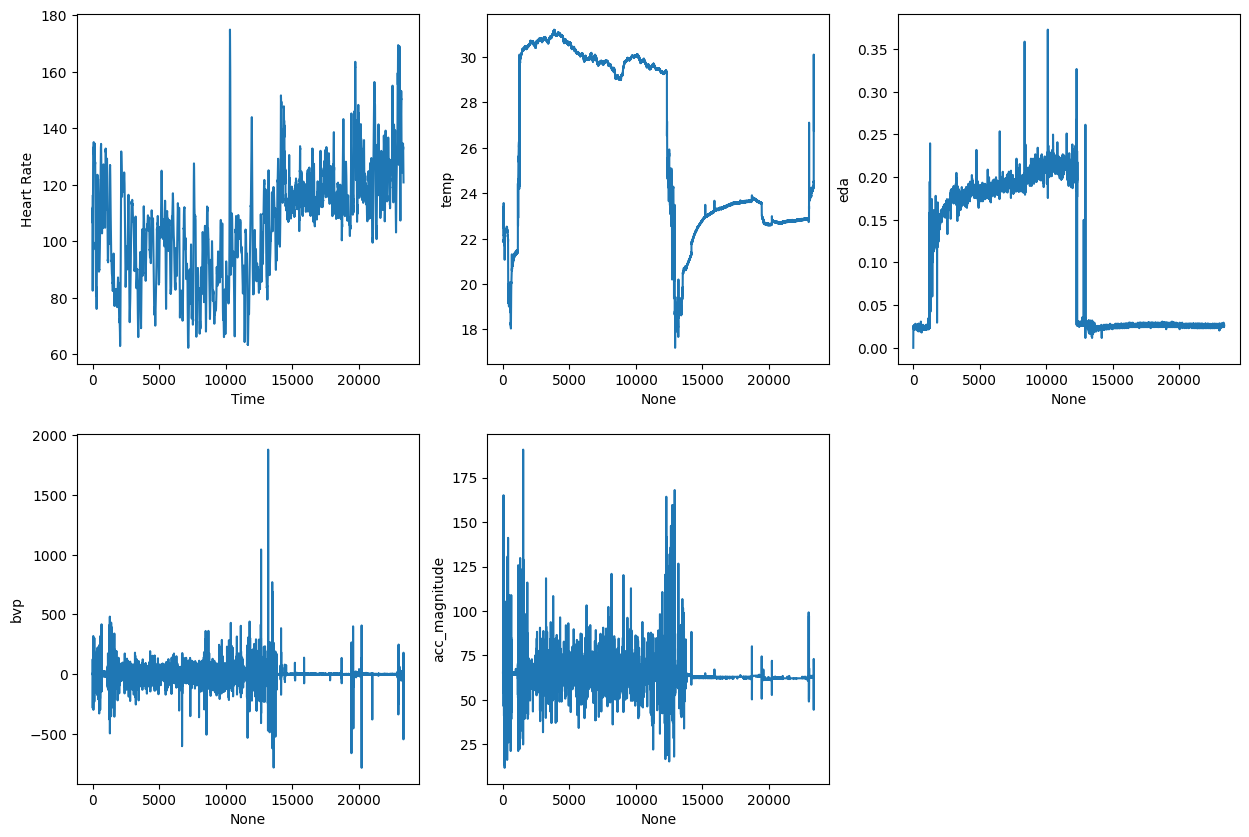

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.lineplot(data = s1_final,
            x = s1_final.index,
            y = 'hr')
plt.xlabel('Time')
plt.ylabel('Heart Rate')


plt.subplot(2, 3, 2)
sns.lineplot(data = s1_final,
            x = s1_final.index,
            y = 'temp')


plt.subplot(2, 3, 3)
sns.lineplot(data = s1_final,
            x = s1_final.index,
            y = 'eda')


plt.subplot(2, 3, 4)
sns.lineplot(data = s1_final,
            x = s1_final.index,
            y = 'bvp')

plt.subplot(2, 3, 5)
sns.lineplot(data = s1_final,
            x = s1_final.index,
            y = 'acc_magnitude')

plt.show()

These graphs display the common ways to measure stress such as EDA, BVP, temperature, and heartrate during the final exam. The heartrate graph fluctuates significantly over the period, potentially because of stress levels, or anxiety. The temperature graph has an increase, with a sudden drop. This could be because of room conditions, body movement or sweating. EDA, or electrodermal activity rises quickly, with multiple spikes throughout. This could be because of stress, cognitive load, or nervousness. BVP has many spikes however in a similar rage throughout most of the graph. Including many large spikes. This could be because of stress responses, or arousal. The ACC magnitiude has many large spikes with a fairly steady pace towards the end. This could be because of fidgeting, restlessness during the exam, or anxiety.

In [ ]:
s1_midterm1_acc= pd.read_csv(midterm1_s1+'/ACC.csv')
s1_midterm1_acc.head()

,1539435366.000000,1539435366.000000,1539435366.000000.1
0,32.0,32.0,32.0
1,-3.0,-62.0,12.0
2,-3.0,-62.0,12.0
3,-3.0,-62.0,12.0
4,-3.0,-62.0,12.0


In [ ]:
s1_midterm1_acc.columns = ['x', 'y', 'z']
s1_midterm1_acc.head()

,x,y,z
0,32.0,32.0,32.0
1,-3.0,-62.0,12.0
2,-3.0,-62.0,12.0
3,-3.0,-62.0,12.0
4,-3.0,-62.0,12.0


In [ ]:
sampling_freq = s1_midterm1_acc.iloc[0].values
sampling_freq

array([32., 32., 32.])

In [ ]:
acc_midterm1_s1 = s1_midterm1_acc.iloc[1:].copy().reset_index(drop=True)
acc_midterm1_s1

,x,y,z
0,-3.0,-62.0,12.0
1,-3.0,-62.0,12.0
2,-3.0,-62.0,12.0
3,-3.0,-62.0,12.0
4,-3.0,-62.0,12.0
...,...,...,...
357697,55.0,-19.0,18.0
357698,56.0,-19.0,18.0
357699,55.0,-19.0,18.0
357700,56.0,-20.0,18.0


In [ ]:
acc_midterm1_s1['Time'] = np.round(acc_midterm1_s1.index / sampling_freq[0], 2)

In [ ]:
acc_midterm1_s1

,x,y,z,Time
0,-3.0,-62.0,12.0,0.00
1,-3.0,-62.0,12.0,0.03
2,-3.0,-62.0,12.0,0.06
3,-3.0,-62.0,12.0,0.09
4,-3.0,-62.0,12.0,0.12
...,...,...,...,...
357697,55.0,-19.0,18.0,11178.03
357698,56.0,-19.0,18.0,11178.06
357699,55.0,-19.0,18.0,11178.09
357700,56.0,-20.0,18.0,11178.12


In [ ]:
s1_midterm1_bvp= pd.read_csv(midterm1_s1+'/BVP.csv')
s1_midterm1_bvp.head()

,1539435366.00
0,64.0
1,-0.0
2,-0.0
3,-0.0
4,-0.0


In [ ]:
s1_midterm1_bvp.columns = ['bvp']
bvp_frequency = s1_midterm1_bvp.iloc[0].values

In [ ]:
bvp_midterm1_s1 = s1_midterm1_bvp.iloc[1:].copy().reset_index(drop=True)
bvp_midterm1_s1['Time'] = np.round(bvp_midterm1_s1.index / bvp_frequency[0], 2)
bvp_midterm1_s1.head()

,bvp,Time
0,-0.0,0.00
1,-0.0,0.02
2,-0.0,0.03
3,-0.0,0.05
4,-0.0,0.06


In [ ]:
s1_midterm1_eda= pd.read_csv(midterm1_s1+'/EDA.csv')

In [ ]:
s1_midterm1_eda.columns = ['eda']
eda_frequency = s1_midterm1_eda.iloc[0].values
eda_midterm1_s1 = s1_midterm1_eda.iloc[1:].copy().reset_index(drop=True)
eda_midterm1_s1['Time'] = np.round(eda_midterm1_s1.index / eda_frequency[0], 2)
eda_midterm1_s1.head()

,eda,Time
0,0.000000,0.00
1,0.002563,0.25
2,0.019221,0.50
3,0.021784,0.75
4,0.023065,1.00


In [ ]:
s1_midterm1_hr= pd.read_csv(midterm1_s1+'/HR.csv')

In [ ]:
s1_midterm1_hr.columns = ['hr']
hr_midterm1_s1 = s1_midterm1_hr.iloc[1:].copy().reset_index(drop=True)
hr_midterm1_s1['Time'] = hr_midterm1_s1.index.values.astype('float')
hr_midterm1_s1.head()

,hr,Time
0,84.00,0.0
1,85.00,1.0
2,86.00,2.0
3,86.75,3.0
4,87.40,4.0


In [ ]:
s1_midterm1_ibi = pd.read_csv(midterm1_s1+'/IBI.csv')

In [ ]:
s1_midterm1_ibi

,1539435366.000000,IBI
0,166.788885,0.390643
1,217.697465,0.421894
2,219.775685,0.468771
3,220.181954,0.406269
4,475.599895,0.390643
...,...,...
295,10476.229543,0.562526
296,10561.077177,0.406269
297,10596.078779,0.328140
298,10703.271186,0.375017


In [ ]:
ibi_midterm1_s1 = s1_midterm1_ibi.copy()
ibi_midterm1_s1.columns = ['Time', 'ibi']
ibi_midterm1_s1['Time']= np.round(ibi_midterm1_s1['Time'].values, 2)
ibi_midterm1_s1.head()

,Time,ibi
0,166.79,0.390643
1,217.70,0.421894
2,219.78,0.468771
3,220.18,0.406269
4,475.60,0.390643


In [ ]:
s1_midterm1_temp= pd.read_csv(midterm1_s1+'/TEMP.csv')
s1_midterm1_temp.head()

,1539435366.000000
0,4.00
1,22.51
2,22.51
3,22.51
4,22.51


In [ ]:
s1_midterm1_temp.columns = ['temp']
temp_frequency = s1_midterm1_temp.iloc[0].values
temp_midterm1_s1 = s1_midterm1_temp.iloc[1:].copy().reset_index(drop=True)
temp_midterm1_s1['Time'] = np.round(temp_midterm1_s1.index / temp_frequency[0], 2)
temp_midterm1_s1.head()

,temp,Time
0,22.51,0.00
1,22.51,0.25
2,22.51,0.50
3,22.51,0.75
4,22.51,1.00


In [ ]:
df1 = hr_s1.merge(temp_midterm1_s1,
                 how = 'inner',
                 on = 'Time')
df1.head()

,hr,Time,temp
0,116.00,0.0,22.51
1,82.50,1.0,22.51
2,96.33,2.0,22.51
3,86.25,3.0,22.51
4,98.60,4.0,22.49


In [ ]:
df2 = df1.merge(eda_midterm1_s1,
               how = 'inner',
               on = 'Time')
df2.head()

,hr,Time,temp,eda
0,116.00,0.0,22.51,0.000000
1,82.50,1.0,22.51,0.023065
2,96.33,2.0,22.51,0.023065
3,86.25,3.0,22.51,0.023065
4,98.60,4.0,22.49,0.023065


In [ ]:
df3 = df2.merge(bvp_midterm1_s1,
               how = 'inner',
               on = 'Time')

In [ ]:
df4 = df3.merge(acc_midterm1_s1,
               how = 'inner',
               on = 'Time')

In [ ]:
# set 'Time' as index
df4.set_index('Time',  drop = True)

,hr,temp,eda,bvp,x,y,z
Time,,,,,,,
0.0,116.00,22.51,0.000000,-0.00,-3.0,-62.0,12.0
1.0,82.50,22.51,0.023065,106.81,-3.0,-62.0,12.0
2.0,96.33,22.51,0.023065,12.13,-3.0,-62.0,12.0
3.0,86.25,22.51,0.023065,5.79,-3.0,-62.0,12.0
4.0,98.60,22.49,0.023065,1.15,-3.0,-62.0,12.0
...,...,...,...,...,...,...,...
11173.0,97.55,25.59,0.024347,-0.88,-1.0,-62.0,9.0
11174.0,97.52,25.55,0.025628,0.18,-2.0,-62.0,9.0
11175.0,97.52,25.57,0.025628,0.07,-57.0,-41.0,24.0


In [ ]:
df4['acc_magnitude'] = np.sqrt(df4['x']**2 + df4['y']**2+df4['z']**2)

In [ ]:
s1_midterm1 = df4.copy()

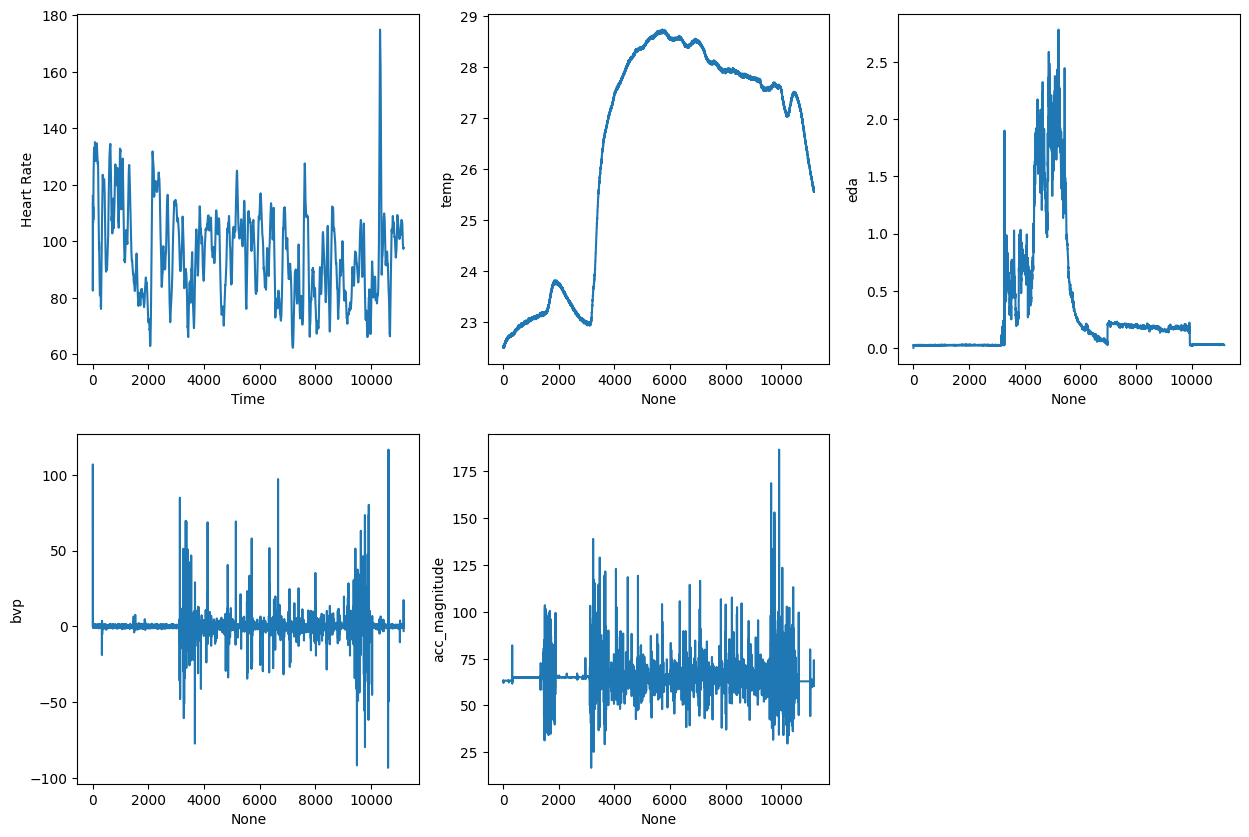

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.lineplot(data = s1_midterm1,
            x = s1_midterm1.index,
            y = 'hr')
plt.xlabel('Time')
plt.ylabel('Heart Rate')


plt.subplot(2, 3, 2)
sns.lineplot(data = s1_midterm1,
            x = s1_midterm1.index,
            y = 'temp')


plt.subplot(2, 3, 3)
sns.lineplot(data = s1_midterm1,
            x = s1_midterm1.index,
            y = 'eda')


plt.subplot(2, 3, 4)
sns.lineplot(data = s1_midterm1,
            x = s1_midterm1.index,
            y = 'bvp')

plt.subplot(2, 3, 5)
sns.lineplot(data = s1_midterm1,
            x = s1_midterm1.index,
            y = 'acc_magnitude')

plt.show()

These graphs show the best ways to measure stress, shown in the y axis, for student one during midterm 1. The heartrate graph fluctuates a lot, with large spikes near the end. This could be because of stress during the exam, or movement like a break during the exam. The temperature graph starts lower, and then rises sharply, with a steady decrease. This shows a physiological change throughout the exam. The EDA graph, is steady with a major spike in the middle of the graph, with a sudden drop at the end. EDA is affected by stressed, so the exam most likely got the student stressed. The BVP graph is fairly steady at first, followed by multiple spikes throughout the rest of the graph. This indicates cardiovascular instablity arousal/movement during certain periods. The ACC Magnitude is low and steady at first, followed by many large spikes ranging from many numbers. This could be because fidgeting and moving during the exam.

In [ ]:
s1_midterm2_acc= pd.read_csv(midterm2_s1+'/ACC.csv')
s1_midterm2_acc.head()

,1541859555.000000,1541859555.000000,1541859555.000000.1
0,32.0,32.0,32.0
1,-2.0,-63.0,7.0
2,-2.0,-62.0,7.0
3,-2.0,-63.0,7.0
4,-3.0,-63.0,7.0


In [ ]:
s1_midterm2_acc.columns = ['x', 'y', 'z']
s1_midterm2_acc.head()

,x,y,z
0,32.0,32.0,32.0
1,-2.0,-63.0,7.0
2,-2.0,-62.0,7.0
3,-2.0,-63.0,7.0
4,-3.0,-63.0,7.0


In [ ]:
sampling_freq = s1_midterm2_acc.iloc[0].values
sampling_freq

array([32., 32., 32.])

In [ ]:
acc_midterm2_s1 = s1_midterm2_acc.iloc[1:].copy().reset_index(drop=True)
acc_midterm2_s1

,x,y,z
0,-2.0,-63.0,7.0
1,-2.0,-62.0,7.0
2,-2.0,-63.0,7.0
3,-3.0,-63.0,7.0
4,-2.0,-63.0,7.0
...,...,...,...
356371,45.0,17.0,33.0
356372,48.0,-6.0,33.0
356373,47.0,6.0,32.0
356374,51.0,0.0,33.0


In [ ]:
acc_midterm2_s1['Time'] = np.round(acc_midterm2_s1.index / sampling_freq[0], 2)

In [ ]:
acc_midterm2_s1

,x,y,z,Time
0,-2.0,-63.0,7.0,0.00
1,-2.0,-62.0,7.0,0.03
2,-2.0,-63.0,7.0,0.06
3,-3.0,-63.0,7.0,0.09
4,-2.0,-63.0,7.0,0.12
...,...,...,...,...
356371,45.0,17.0,33.0,11136.59
356372,48.0,-6.0,33.0,11136.62
356373,47.0,6.0,32.0,11136.66
356374,51.0,0.0,33.0,11136.69


In [ ]:
s1_midterm2_bvp= pd.read_csv(midterm2_s1+'/BVP.csv')
s1_midterm2_bvp.head()

,1541859555.00
0,64.0
1,-0.0
2,-0.0
3,-0.0
4,-0.0


In [ ]:
s1_midterm2_bvp.columns = ['bvp']
bvp_frequency = s1_midterm2_bvp.iloc[0].values

In [ ]:
bvp_midterm2_s1 = s1_midterm2_bvp.iloc[1:].copy().reset_index(drop=True)
bvp_midterm2_s1['Time'] = np.round(bvp_midterm2_s1.index / bvp_frequency[0], 2)
bvp_midterm2_s1.head()

,bvp,Time
0,-0.0,0.00
1,-0.0,0.02
2,-0.0,0.03
3,-0.0,0.05
4,-0.0,0.06


In [ ]:
s1_midterm2_eda= pd.read_csv(midterm2_s1+'/EDA.csv')

In [ ]:
s1_midterm2_eda.columns = ['eda']
eda_frequency = s1_midterm2_eda.iloc[0].values
eda_midterm2_s1 = s1_midterm2_eda.iloc[1:].copy().reset_index(drop=True)
eda_midterm2_s1['Time'] = np.round(eda_midterm2_s1.index / eda_frequency[0], 2)
eda_midterm2_s1.head()

,eda,Time
0,0.000000,0.00
1,0.005125,0.25
2,0.020501,0.50
3,0.021783,0.75
4,0.023064,1.00


In [ ]:
s1_midterm2_hr= pd.read_csv(midterm2_s1+'/HR.csv')

In [ ]:
s1_midterm2_hr.columns = ['hr']
hr_midterm2_s1 = s1_midterm2_hr.iloc[1:].copy().reset_index(drop=True)
hr_midterm2_s1['Time'] = hr_midterm2_s1.index.values.astype('float')
hr_midterm2_s1.head()

,hr,Time
0,97.00,0.0
1,74.00,1.0
2,86.33,2.0
3,78.50,3.0
4,86.80,4.0


In [ ]:
s1_midterm2_ibi = pd.read_csv(midterm2_s1+'/IBI.csv')

In [ ]:
ibi_midterm2_s1 = s1_midterm2_ibi.copy()
ibi_midterm2_s1.columns = ['Time', 'ibi']
ibi_midterm2_s1['Time']= np.round(ibi_midterm2_s1['Time'].values, 2)
ibi_midterm2_s1.head()

,Time,ibi
0,11.95,0.359391
1,283.67,0.625029
2,301.62,0.859414
3,302.25,0.625029
4,328.33,0.703157


In [ ]:
s1_midterm2_temp= pd.read_csv(midterm2_s1+'/TEMP.csv')
s1_midterm2_temp.head()

,1541859555.000000
0,4.00
1,21.79
2,21.79
3,21.79
4,21.79


In [ ]:
s1_midterm2_temp.columns = ['temp']
temp_frequency = s1_midterm2_temp.iloc[0].values
temp_midterm2_s1 = s1_midterm2_temp.iloc[1:].copy().reset_index(drop=True)
temp_midterm2_s1['Time'] = np.round(temp_midterm2_s1.index / temp_frequency[0], 2)
temp_midterm2_s1.head()

,temp,Time
0,21.79,0.00
1,21.79,0.25
2,21.79,0.50
3,21.79,0.75
4,21.79,1.00


In [ ]:
df1 = hr_s1.merge(temp_midterm2_s1,
                 how = 'inner',
                 on = 'Time')
df1.head()

,hr,Time,temp
0,116.00,0.0,21.79
1,82.50,1.0,21.79
2,96.33,2.0,21.77
3,86.25,3.0,21.77
4,98.60,4.0,21.79


In [ ]:
df2 = df1.merge(eda_midterm2_s1,
               how = 'inner',
               on = 'Time')
df2.head()

,hr,Time,temp,eda
0,116.00,0.0,21.79,0.000000
1,82.50,1.0,21.79,0.023064
2,96.33,2.0,21.77,0.023064
3,86.25,3.0,21.77,0.021783
4,98.60,4.0,21.79,0.023064


In [ ]:
df3 = df2.merge(bvp_midterm2_s1,
               how = 'inner',
               on = 'Time')

In [ ]:
df4 = df3.merge(acc_midterm2_s1,
               how = 'inner',
               on = 'Time')

In [ ]:
# set 'Time' as index
df4.set_index('Time',  drop = True)

,hr,temp,eda,bvp,x,y,z
Time,,,,,,,
0.0,116.00,21.79,0.000000,-0.00,-2.0,-63.0,7.0
1.0,82.50,21.79,0.023064,123.23,-2.0,-63.0,7.0
2.0,96.33,21.77,0.023064,-79.79,-2.0,-63.0,7.0
3.0,86.25,21.77,0.021783,27.76,-2.0,-63.0,7.0
4.0,98.60,21.79,0.023064,0.15,-3.0,-62.0,7.0
...,...,...,...,...,...,...,...
11131.0,105.25,23.95,0.024345,-9.65,9.0,62.0,-14.0
11132.0,104.80,23.91,0.025627,-4.42,16.0,57.0,28.0
11133.0,104.35,23.87,0.025627,-2.73,30.0,37.0,50.0


In [ ]:
df4['acc_magnitude'] = np.sqrt(df4['x']**2 + df4['y']**2+df4['z']**2)

In [ ]:
s1_midterm2 = df4.copy()

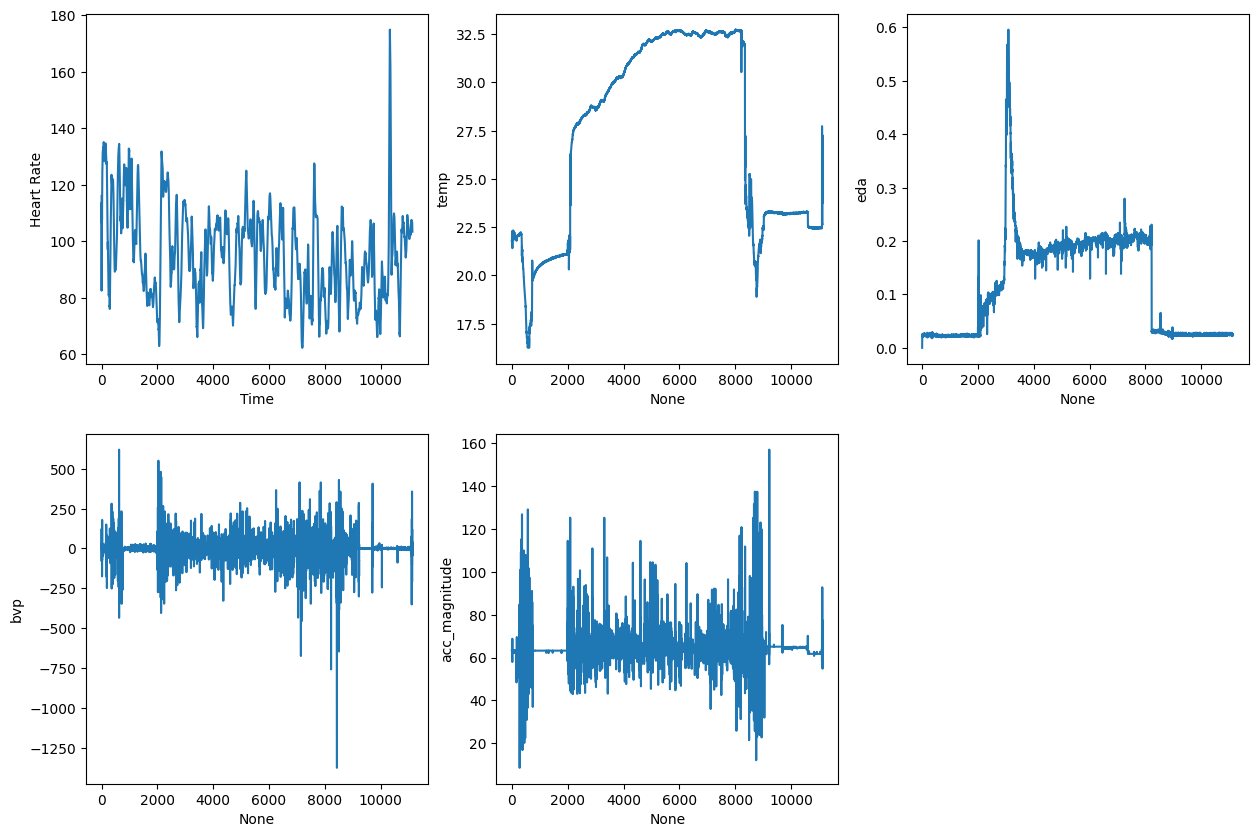

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.lineplot(data = s1_midterm2,
            x = s1_midterm2.index,
            y = 'hr')
plt.xlabel('Time')
plt.ylabel('Heart Rate')


plt.subplot(2, 3, 2)
sns.lineplot(data = s1_midterm2,
            x = s1_midterm2.index,
            y = 'temp')


plt.subplot(2, 3, 3)
sns.lineplot(data = s1_midterm2,
            x = s1_midterm2.index,
            y = 'eda')


plt.subplot(2, 3, 4)
sns.lineplot(data = s1_midterm2,
            x = s1_midterm2.index,
            y = 'bvp')

plt.subplot(2, 3, 5)
sns.lineplot(data = s1_midterm2,
            x = s1_midterm2.index,
            y = 'acc_magnitude')

plt.show()

These graphs show the common ways to measure stress for student one during midterm 2. The heart rate graph starts high and then stays elevated, with big spikes at the end. The temperature graph starts lower, with a steady increase followed by a large drop. This could be because of a stressful portion of the exam. The EDA graph is very low at the beginning, with a sharp spike in the middle, followed by the graph being fair steady with a maojr drop at the end. The large drop indicates a high amount of stress for the student. The BVP graph starts very high, with a sudden drop around value 8,000. This suggests cardiovascualr changes during the same middle period, causing the major drop. The ACC graph starts low, and the fluctates heavily throughout the graph. This could be because of a break during the exam, or fidgting because of anxiety.

In [ ]:
# do same procedures for student #3 (final)
s3_final_acc= pd.read_csv(final_s3+'/ACC.csv')
s3_final_acc.head()

,1544027334.000000,1544027334.000000,1544027334.000000.1
0,32.0,32.0,32.0
1,-1.0,-62.0,7.0
2,0.0,-62.0,7.0
3,0.0,-62.0,8.0
4,-1.0,-63.0,7.0


In [ ]:
s3_final_acc.columns = ['x', 'y', 'z']
s3_final_acc.head()

,x,y,z
0,32.0,32.0,32.0
1,-1.0,-62.0,7.0
2,0.0,-62.0,7.0
3,0.0,-62.0,8.0
4,-1.0,-63.0,7.0


In [ ]:
sampling_freq = s3_final_acc.iloc[0].values
sampling_freq

array([32., 32., 32.])

In [ ]:
acc_final_s3 = s3_final_acc.iloc[1:].copy().reset_index(drop=True)
acc_final_s3

,x,y,z
0,-1.0,-62.0,7.0
1,0.0,-62.0,7.0
2,0.0,-62.0,8.0
3,-1.0,-63.0,7.0
4,-1.0,-62.0,7.0
...,...,...,...
826303,-59.0,-19.0,-17.0
826304,-61.0,-19.0,-21.0
826305,-59.0,-19.0,-24.0
826306,-55.0,-21.0,-17.0


In [ ]:
acc_final_s3['Time'] = np.round(acc_final_s3.index / sampling_freq[0], 2)

In [ ]:
acc_final_s3

,x,y,z,Time
0,-1.0,-62.0,7.0,0.00
1,0.0,-62.0,7.0,0.03
2,0.0,-62.0,8.0,0.06
3,-1.0,-63.0,7.0,0.09
4,-1.0,-62.0,7.0,0.12
...,...,...,...,...
826303,-59.0,-19.0,-17.0,25821.97
826304,-61.0,-19.0,-21.0,25822.00
826305,-59.0,-19.0,-24.0,25822.03
826306,-55.0,-21.0,-17.0,25822.06


In [ ]:
s3_final_bvp= pd.read_csv(final_s3+'/BVP.csv')
s3_final_bvp.head()

,1544027334.00
0,64.0
1,-0.0
2,-0.0
3,-0.0
4,-0.0


In [ ]:
s3_final_bvp.columns = ['bvp']
bvp_frequency = s3_final_bvp.iloc[0].values

In [ ]:
bvp_final_s3 = s3_final_bvp.iloc[1:].copy().reset_index(drop=True)
bvp_final_s3['Time'] = np.round(bvp_final_s3.index / bvp_frequency[0], 2)
bvp_final_s3.head()

,bvp,Time
0,-0.0,0.00
1,-0.0,0.02
2,-0.0,0.03
3,-0.0,0.05
4,-0.0,0.06


In [ ]:
s3_final_eda= pd.read_csv(final_s3+'/EDA.csv')

In [ ]:
s3_final_eda.columns = ['eda']
eda_frequency = s3_final_eda.iloc[0].values
eda_final_s3 = s3_final_eda.iloc[1:].copy().reset_index(drop=True)
eda_final_s3['Time'] = np.round(eda_final_s3.index / eda_frequency[0], 2)
eda_final_s3.head()

,eda,Time
0,0.000000,0.00
1,0.003844,0.25
2,0.016658,0.50
3,0.017940,0.75
4,0.017940,1.00


In [ ]:
s3_final_hr= pd.read_csv(final_s3+'/HR.csv')

In [ ]:
s3_final_hr.columns = ['hr']
hr_final_s3 = s3_final_hr.iloc[1:].copy().reset_index(drop=True)
hr_final_s3['Time'] = hr_final_s3.index.values.astype('float')
hr_final_s3.head()

,hr,Time
0,111.00,0.0
1,81.50,1.0
2,94.00,2.0
3,88.75,3.0
4,98.40,4.0


In [ ]:
s3_final_ibi = pd.read_csv(final_s3+'/IBI.csv')

In [ ]:
ibi_final_s3 = s3_final_ibi.copy()
ibi_final_s3.columns = ['Time', 'ibi']
ibi_final_s3['Time']= np.round(ibi_final_s3['Time'].values, 2)
ibi_final_s3.head()

,Time,ibi
0,19.59,0.359391
1,30.02,0.437520
2,30.41,0.390643
3,30.77,0.359391
4,149.87,0.453146


In [ ]:
s3_final_temp= pd.read_csv(final_s3+'/TEMP.csv')
s3_final_temp.head()

,1544027334.000000
0,4.00
1,21.69
2,21.69
3,21.69
4,21.69


In [ ]:
s3_final_temp.columns = ['temp']
temp_frequency = s3_final_temp.iloc[0].values
temp_final_s3 = s3_final_temp.iloc[1:].copy().reset_index(drop=True)
temp_final_s3['Time'] = np.round(temp_final_s3.index / temp_frequency[0], 2)
temp_final_s3.head()

,temp,Time
0,21.69,0.00
1,21.69,0.25
2,21.69,0.50
3,21.69,0.75
4,21.69,1.00


In [ ]:
df1 = hr_final_s3.merge(temp_final_s3,
                 how = 'inner',
                 on = 'Time')
df1.head()

,hr,Time,temp
0,111.00,0.0,21.69
1,81.50,1.0,21.69
2,94.00,2.0,21.69
3,88.75,3.0,21.67
4,98.40,4.0,21.69


In [ ]:
df2 = df1.merge(eda_final_s3,
               how = 'inner',
               on = 'Time')
df2.head()

,hr,Time,temp,eda
0,111.00,0.0,21.69,0.000000
1,81.50,1.0,21.69,0.017940
2,94.00,2.0,21.69,0.016658
3,88.75,3.0,21.67,0.015377
4,98.40,4.0,21.69,0.014096


In [ ]:
df3 = df2.merge(bvp_final_s3,
               how = 'inner',
               on = 'Time')

In [ ]:
df4 = df3.merge(acc_final_s3,
               how = 'inner',
               on = 'Time')

In [ ]:
# set 'Time' as index
df4.set_index('Time',  drop = True)

,hr,temp,eda,bvp,x,y,z
Time,,,,,,,
0.0,111.00,21.69,0.000000,-0.00,-1.0,-62.0,7.0
1.0,81.50,21.69,0.017940,127.80,-1.0,-62.0,7.0
2.0,94.00,21.69,0.016658,-111.61,-1.0,-62.0,7.0
3.0,88.75,21.67,0.015377,7.69,-1.0,-62.0,7.0
4.0,98.40,21.69,0.014096,4.83,-1.0,-62.0,7.0
...,...,...,...,...,...,...,...
25807.0,95.82,23.25,0.000000,-131.33,-2.0,63.0,8.0
25808.0,94.80,23.23,0.000000,-9.88,-1.0,64.0,8.0
25809.0,94.83,23.21,0.000000,119.86,-1.0,63.0,8.0


In [ ]:
df4['acc_magnitude'] = np.sqrt(df4['x']**2 + df4['y']**2+df4['z']**2)

In [ ]:
s3_final = df4.copy()

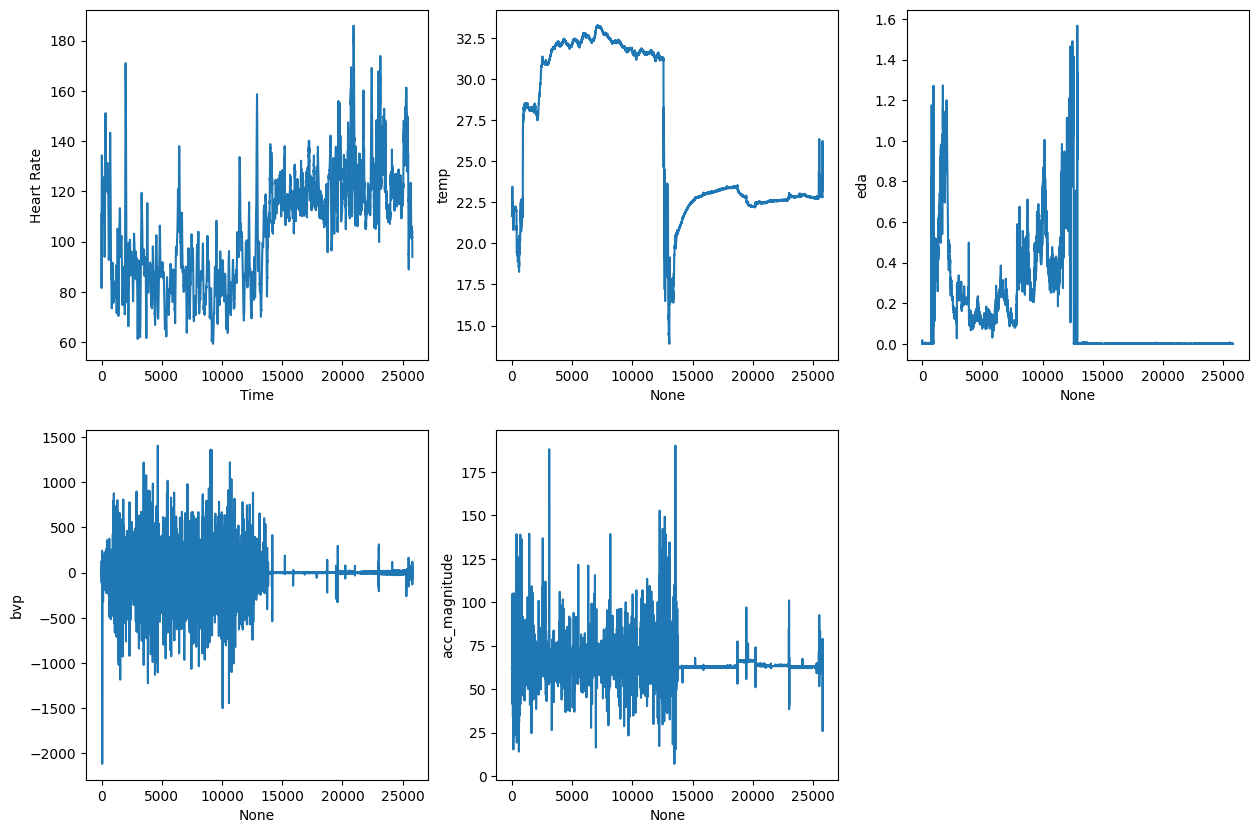

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.lineplot(data = s3_final,
            x = s3_final.index,
            y = 'hr')
plt.xlabel('Time')
plt.ylabel('Heart Rate')


plt.subplot(2, 3, 2)
sns.lineplot(data = s3_final,
            x = s3_final.index,
            y = 'temp')


plt.subplot(2, 3, 3)
sns.lineplot(data = s3_final,
            x = s3_final.index,
            y = 'eda')


plt.subplot(2, 3, 4)
sns.lineplot(data = s3_final,
            x = s3_final.index,
            y = 'bvp')

plt.subplot(2, 3, 5)
sns.lineplot(data = s3_final,
            x = s3_final.index,
            y = 'acc_magnitude')

plt.show()

These graphs show the same things as the student 1, but for student three during the final exam. The heartrate graph fluctates heavily, which indicates high stress levels for short periods, rather than a long period. The temptrerature graph rises quickly, with a sudden drop. This could be because the students psychiological state changed during the exam, such as a stressful question appearing causing higher stress. The EDA graph spikes early on, with a drop leading to the graph being steady. This shows that the student was stressed for a long period of time, but then suddenly calmed down. The BVP graph fluctuates heavily in the middle, with it being much more steady later on. This directly correlates to the students cardiovascular activity. The ACC graph starts fairly high, with many spikes. This shows that the student was more physically active or restless earlier in the exam, with movement decreasing later on in the exam.

In [ ]:
# midterm 1
s3_midterm1_acc= pd.read_csv(midterm1_s3+'/ACC.csv')
s3_midterm1_acc.head()

,1539435408.000000,1539435408.000000,1539435408.000000.1
0,32.0,32.0,32.0
1,-1.0,-62.0,12.0
2,-1.0,-62.0,12.0
3,-2.0,-62.0,13.0
4,-1.0,-61.0,12.0


In [ ]:
s3_midterm1_acc.columns = ['x', 'y', 'z']
s3_midterm1_acc.head()

,x,y,z
0,32.0,32.0,32.0
1,-1.0,-62.0,12.0
2,-1.0,-62.0,12.0
3,-2.0,-62.0,13.0
4,-1.0,-61.0,12.0


In [ ]:
sampling_freq = s3_final_acc.iloc[0].values
sampling_freq

array([32., 32., 32.])

In [ ]:
acc_midterm1_s3 = s3_midterm1_acc.iloc[1:].copy().reset_index(drop=True)
acc_midterm1_s3

,x,y,z
0,-1.0,-62.0,12.0
1,-1.0,-62.0,12.0
2,-2.0,-62.0,13.0
3,-1.0,-61.0,12.0
4,-1.0,-62.0,13.0
...,...,...,...
390811,26.0,9.0,57.0
390812,26.0,9.0,58.0
390813,25.0,10.0,58.0
390814,25.0,9.0,57.0


In [ ]:
acc_midterm1_s3['Time'] = np.round(acc_midterm1_s3.index / sampling_freq[0], 2)

In [ ]:

acc_midterm1_s3

,x,y,z,Time
0,-1.0,-62.0,12.0,0.00
1,-1.0,-62.0,12.0,0.03
2,-2.0,-62.0,13.0,0.06
3,-1.0,-61.0,12.0,0.09
4,-1.0,-62.0,13.0,0.12
...,...,...,...,...
390811,26.0,9.0,57.0,12212.84
390812,26.0,9.0,58.0,12212.88
390813,25.0,10.0,58.0,12212.91
390814,25.0,9.0,57.0,12212.94


In [ ]:
s3_midterm1_bvp= pd.read_csv(midterm1_s3+'/BVP.csv')
s3_midterm1_bvp.head()

,1539435408.00
0,64.0
1,-0.0
2,-0.0
3,-0.0
4,-0.0


In [ ]:
s3_midterm1_bvp.columns = ['bvp']
bvp_frequency = s3_midterm1_bvp.iloc[0].values

In [ ]:
bvp_midterm1_s3 = s3_midterm1_bvp.iloc[1:].copy().reset_index(drop=True)
bvp_midterm1_s3['Time'] = np.round(bvp_midterm1_s3.index / bvp_frequency[0], 2)
bvp_midterm1_s3.head()

,bvp,Time
0,-0.0,0.00
1,-0.0,0.02
2,-0.0,0.03
3,-0.0,0.05
4,-0.0,0.06


In [ ]:
s3_midterm1_eda= pd.read_csv(midterm1_s3+'/EDA.csv')

In [ ]:
s3_midterm1_eda.columns = ['eda']
eda_frequency = s3_midterm1_eda.iloc[0].values
eda_midterm1_s3 = s3_midterm1_eda.iloc[1:].copy().reset_index(drop=True)
eda_midterm1_s3['Time'] = np.round(eda_midterm1_s3.index / eda_frequency[0], 2)
eda_midterm1_s3.head()

,eda,Time
0,0.000000,0.00
1,0.001282,0.25
2,0.016660,0.50
3,0.017942,0.75
4,0.016660,1.00


In [ ]:
s3_midterm1_hr= pd.read_csv(midterm1_s3+'/HR.csv')

In [ ]:
s3_midterm1_hr.columns = ['hr']
hr_midterm1_s3 = s3_midterm1_hr.iloc[1:].copy().reset_index(drop=True)
hr_midterm1_s3['Time'] = hr_midterm1_s3.index.values.astype('float')
hr_midterm1_s3.head()

,hr,Time
0,110.00,0.0
1,83.50,1.0
2,92.67,2.0
3,84.00,3.0
4,92.80,4.0


In [ ]:
s3_midterm1_ibi = pd.read_csv(midterm1_s3+'/IBI.csv')

In [ ]:
ibi_midterm1_s3 = s3_midterm1_ibi.copy()
ibi_midterm1_s3.columns = ['Time', 'ibi']
ibi_midterm1_s3['Time']= np.round(ibi_midterm1_s3['Time'].values, 2)
ibi_midterm1_s3.head()

,Time,ibi
0,95.90,0.484397
1,119.04,0.578151
2,202.65,0.390643
3,203.01,0.359391
4,203.43,0.421894


In [ ]:
s3_midterm1_temp= pd.read_csv(midterm1_s3+'/TEMP.csv')
s3_midterm1_temp.head()

,1539435408.000000
0,4.00
1,22.07
2,22.07
3,22.07
4,22.07


In [ ]:
s3_midterm1_temp.columns = ['temp']
temp_frequency = s3_midterm1_temp.iloc[0].values
temp_midterm1_s3 = s3_midterm1_temp.iloc[1:].copy().reset_index(drop=True)
temp_midterm1_s3['Time'] = np.round(temp_midterm1_s3.index / temp_frequency[0], 2)
temp_midterm1_s3.head()

,temp,Time
0,22.07,0.00
1,22.07,0.25
2,22.07,0.50
3,22.07,0.75
4,22.07,1.00


In [ ]:
df1 = hr_midterm1_s3.merge(temp_midterm1_s3,
                 how = 'inner',
                 on = 'Time')
df1.head()

,hr,Time,temp
0,110.00,0.0,22.07
1,83.50,1.0,22.07
2,92.67,2.0,22.09
3,84.00,3.0,22.09
4,92.80,4.0,22.11


In [ ]:
df2 = df1.merge(eda_midterm1_s3,
               how = 'inner',
               on = 'Time')
df2.head()

,hr,Time,temp,eda
0,110.00,0.0,22.07,0.000000
1,83.50,1.0,22.07,0.016660
2,92.67,2.0,22.09,0.016660
3,84.00,3.0,22.09,0.015379
4,92.80,4.0,22.11,0.014097


In [ ]:
df3 = df2.merge(bvp_midterm1_s3,
               how = 'inner',
               on = 'Time')

In [ ]:
df4 = df3.merge(acc_midterm1_s3,
               how = 'inner',
               on = 'Time')

In [ ]:
# set 'Time' as index
df4.set_index('Time',  drop = True)

,hr,temp,eda,bvp,x,y,z
Time,,,,,,,
0.0,110.00,22.07,0.000000,-0.00,-1.0,-62.0,12.0
1.0,83.50,22.07,0.016660,108.36,-1.0,-62.0,13.0
2.0,92.67,22.09,0.016660,12.75,-1.0,-62.0,13.0
3.0,84.00,22.09,0.015379,6.09,-1.0,-62.0,13.0
4.0,92.80,22.11,0.014097,1.37,-1.0,-62.0,12.0
...,...,...,...,...,...,...,...
12198.0,101.78,23.61,0.001282,0.11,38.0,-4.0,50.0
12199.0,101.90,23.61,0.002563,-0.08,37.0,-6.0,51.0
12200.0,102.03,23.61,0.001282,0.87,34.0,-4.0,53.0


In [ ]:
df4['acc_magnitude'] = np.sqrt(df4['x']**2 + df4['y']**2+df4['z']**2)

In [ ]:
s3_midterm1 = df4.copy()

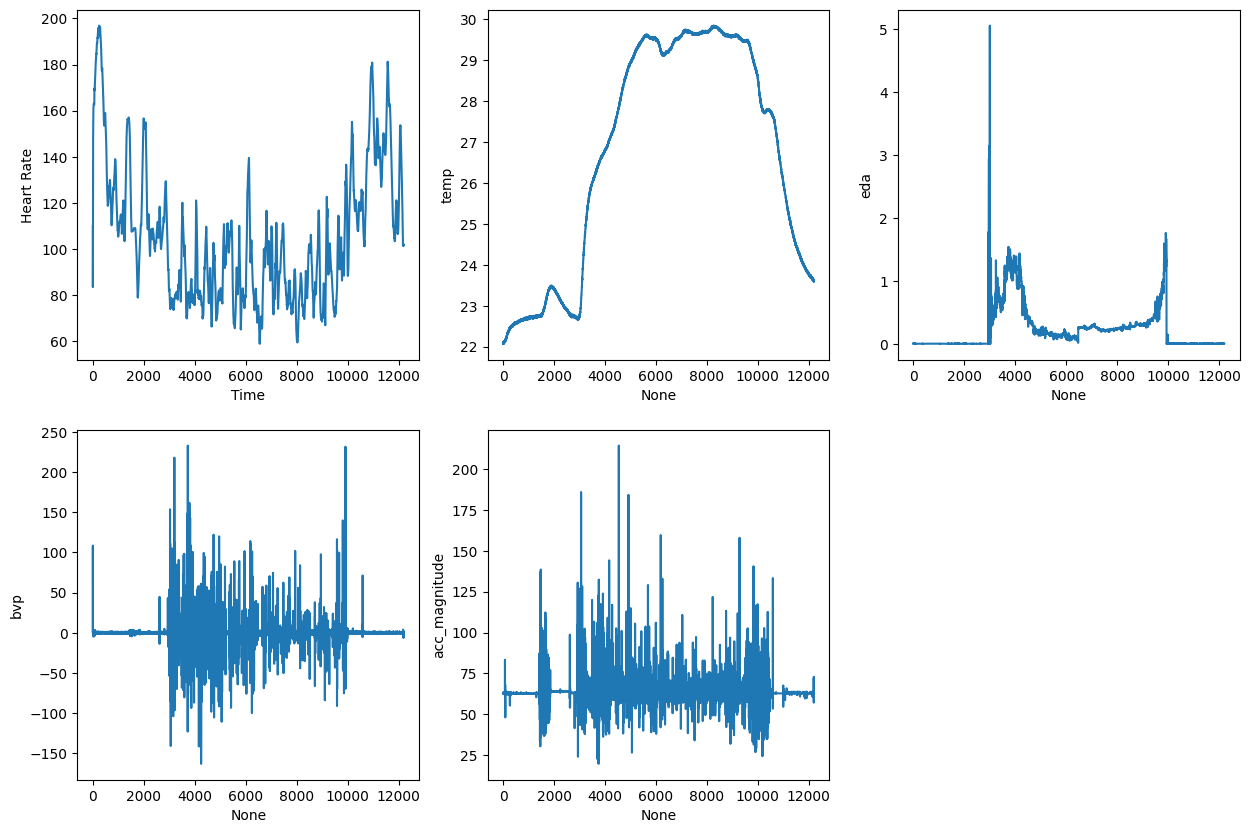

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.lineplot(data = s3_midterm1,
            x = s3_midterm1.index,
            y = 'hr')
plt.xlabel('Time')
plt.ylabel('Heart Rate')


plt.subplot(2, 3, 2)
sns.lineplot(data = s3_midterm1,
            x = s3_midterm1.index,
            y = 'temp')


plt.subplot(2, 3, 3)
sns.lineplot(data = s3_midterm1,
            x = s3_midterm1.index,
            y = 'eda')


plt.subplot(2, 3, 4)
sns.lineplot(data = s3_midterm1,
            x = s3_midterm1.index,
            y = 'bvp')

plt.subplot(2, 3, 5)
sns.lineplot(data = s3_midterm1,
            x = s3_midterm1.index,
            y = 'acc_magnitude')

plt.show()

These graphs show the ways to measure stress for student 3 midterm 1. The heart rate graph fluctates heavily, spiking from 60 to 190 beats. This is a large indicator of stress during the exam. The temperature graph starts very low, with a large increase creating a hump shape, meaning the students temperature steadily rose during the exam. The EDA graph starts steady, with a large spike. Eventually the spike comes down, but it still isn't consistent during the rest of the graph. The BVP starts with a major spike, resulting in fluctations throughout the graph. This means that their cardiovascualr system became very unstable during the exam. The ACC graph has many spikes. Indictating that the student was barely moving in the beginning, with the student being much more active towards the end of the exam.

In [ ]:
# midterm 2
s3_midterm2_acc= pd.read_csv(midterm2_s3+'/ACC.csv')
s3_midterm2_acc.head()

,1541859394.000000,1541859394.000000,1541859394.000000.1
0,32.0,32.0,32.0
1,-4.0,64.0,6.0
2,-4.0,64.0,6.0
3,-4.0,64.0,6.0
4,-4.0,64.0,6.0


In [ ]:
s3_midterm2_acc.columns = ['x', 'y', 'z']
s3_midterm2_acc.head()

,x,y,z
0,32.0,32.0,32.0
1,-4.0,64.0,6.0
2,-4.0,64.0,6.0
3,-4.0,64.0,6.0
4,-4.0,64.0,6.0


In [ ]:
sampling_freq = s3_final_acc.iloc[0].values
sampling_freq

array([32., 32., 32.])

In [ ]:
acc_midterm2_s3 = s3_midterm2_acc.iloc[1:].copy().reset_index(drop=True)
acc_midterm2_s3

,x,y,z
0,-4.0,64.0,6.0
1,-4.0,64.0,6.0
2,-4.0,64.0,6.0
3,-4.0,64.0,6.0
4,-4.0,64.0,6.0
...,...,...,...
327835,16.0,3.0,-63.0
327836,13.0,2.0,-62.0
327837,4.0,-1.0,-63.0
327838,9.0,2.0,-62.0


In [ ]:
acc_midterm2_s3['Time'] = np.round(acc_midterm2_s3.index / sampling_freq[0], 2)

In [ ]:
acc_midterm2_s3

,x,y,z,Time
0,-4.0,64.0,6.0,0.00
1,-4.0,64.0,6.0,0.03
2,-4.0,64.0,6.0,0.06
3,-4.0,64.0,6.0,0.09
4,-4.0,64.0,6.0,0.12
...,...,...,...,...
327835,16.0,3.0,-63.0,10244.84
327836,13.0,2.0,-62.0,10244.88
327837,4.0,-1.0,-63.0,10244.91
327838,9.0,2.0,-62.0,10244.94


In [ ]:
s3_midterm2_bvp= pd.read_csv(midterm2_s3+'/BVP.csv')
s3_midterm2_bvp.head()

,1541859394.00
0,64.0
1,-0.0
2,-0.0
3,-0.0
4,-0.0


In [ ]:
s3_midterm2_bvp.columns = ['bvp']
bvp_frequency = s3_midterm2_bvp.iloc[0].values

In [ ]:
bvp_midterm2_s3 = s3_midterm2_bvp.iloc[1:].copy().reset_index(drop=True)
bvp_midterm2_s3['Time'] = np.round(bvp_midterm2_s3.index / bvp_frequency[0], 2)
bvp_midterm2_s3.head()

,bvp,Time
0,-0.0,0.00
1,-0.0,0.02
2,-0.0,0.03
3,-0.0,0.05
4,-0.0,0.06


In [ ]:
s3_midterm2_eda= pd.read_csv(midterm2_s3+'/EDA.csv')

In [ ]:
s3_midterm2_eda.columns = ['eda']
eda_frequency = s3_midterm2_eda.iloc[0].values
eda_midterm2_s3 = s3_midterm2_eda.iloc[1:].copy().reset_index(drop=True)
eda_midterm2_s3['Time'] = np.round(eda_midterm2_s3.index / eda_frequency[0], 2)
eda_midterm2_s3.head()

,eda,Time
0,0.000000,0.00
1,0.002563,0.25
2,0.016659,0.50
3,0.017941,0.75
4,0.017941,1.00


In [ ]:
s3_midterm2_hr= pd.read_csv(midterm2_s3+'/HR.csv')

In [ ]:

s3_midterm2_hr.columns = ['hr']
hr_midterm2_s3 = s3_midterm2_hr.iloc[1:].copy().reset_index(drop=True)
hr_midterm2_s3['Time'] = hr_midterm2_s3.index.values.astype('float')
hr_midterm2_s3.head()

,hr,Time
0,95.0,0.0
1,78.0,1.0
2,88.0,2.0
3,95.0,3.0
4,85.6,4.0


In [ ]:
s3_midterm2_ibi = pd.read_csv(midterm2_s3+'/IBI.csv')

In [ ]:
ibi_midterm2_s3 = s3_midterm2_ibi.copy()
ibi_midterm2_s3.columns = ['Time', 'ibi']
ibi_midterm2_s3['Time']= np.round(ibi_midterm2_s3['Time'].values, 2)
ibi_midterm2_s3.head()

,Time,ibi
0,163.40,0.421894
1,163.91,0.515649
2,172.15,0.406269
3,172.51,0.359391
4,172.82,0.312514


In [ ]:
s3_midterm2_temp= pd.read_csv(midterm2_s3+'/TEMP.csv')
s3_midterm2_temp.head()

,1541859394.000000
0,4.00
1,22.15
2,22.15
3,22.15
4,22.15


In [ ]:
s3_midterm2_temp.columns = ['temp']
temp_frequency = s3_midterm2_temp.iloc[0].values
temp_midterm2_s3 = s3_midterm2_temp.iloc[1:].copy().reset_index(drop=True)
temp_midterm2_s3['Time'] = np.round(temp_midterm2_s3.index / temp_frequency[0], 2)
temp_midterm2_s3.head()

,temp,Time
0,22.15,0.00
1,22.15,0.25
2,22.15,0.50
3,22.15,0.75
4,22.15,1.00


In [ ]:
df1 = hr_midterm2_s3.merge(temp_midterm2_s3,
                 how = 'inner',
                 on = 'Time')
df1.head()

,hr,Time,temp
0,95.0,0.0,22.15
1,78.0,1.0,22.15
2,88.0,2.0,22.15
3,95.0,3.0,22.17
4,85.6,4.0,22.33


In [ ]:
df2 = df1.merge(eda_midterm2_s3,
               how = 'inner',
               on = 'Time')
df2.head()

,hr,Time,temp,eda
0,95.0,0.0,22.15,0.000000
1,78.0,1.0,22.15,0.017941
2,88.0,2.0,22.15,0.017941
3,95.0,3.0,22.17,0.017941
4,85.6,4.0,22.33,0.016659


In [ ]:
df3 = df2.merge(bvp_midterm2_s3,
               how = 'inner',
               on = 'Time')

In [ ]:
df4 = df3.merge(acc_midterm2_s3,
               how = 'inner',
               on = 'Time')

In [ ]:
# set 'Time' as index
df4.set_index('Time',  drop = True)

,hr,temp,eda,bvp,x,y,z
Time,,,,,,,
0.0,95.00,22.15,0.000000,-0.00,-4.0,64.0,6.0
1.0,78.00,22.15,0.017941,98.54,-4.0,64.0,6.0
2.0,88.00,22.15,0.017941,90.15,-4.0,64.0,6.0
3.0,95.00,22.17,0.017941,19.35,-4.0,63.0,6.0
4.0,85.60,22.33,0.016659,14.00,-3.0,64.0,6.0
...,...,...,...,...,...,...,...
10230.0,117.97,29.71,0.001281,-9.59,-45.0,-8.0,47.0
10231.0,116.98,28.87,0.000000,43.09,-54.0,-26.0,33.0
10232.0,116.15,29.31,0.000000,66.07,-22.0,3.0,56.0


In [ ]:
df4['acc_magnitude'] = np.sqrt(df4['x']**2 + df4['y']**2+df4['z']**2)

In [ ]:
s3_midterm2 = df4.copy()

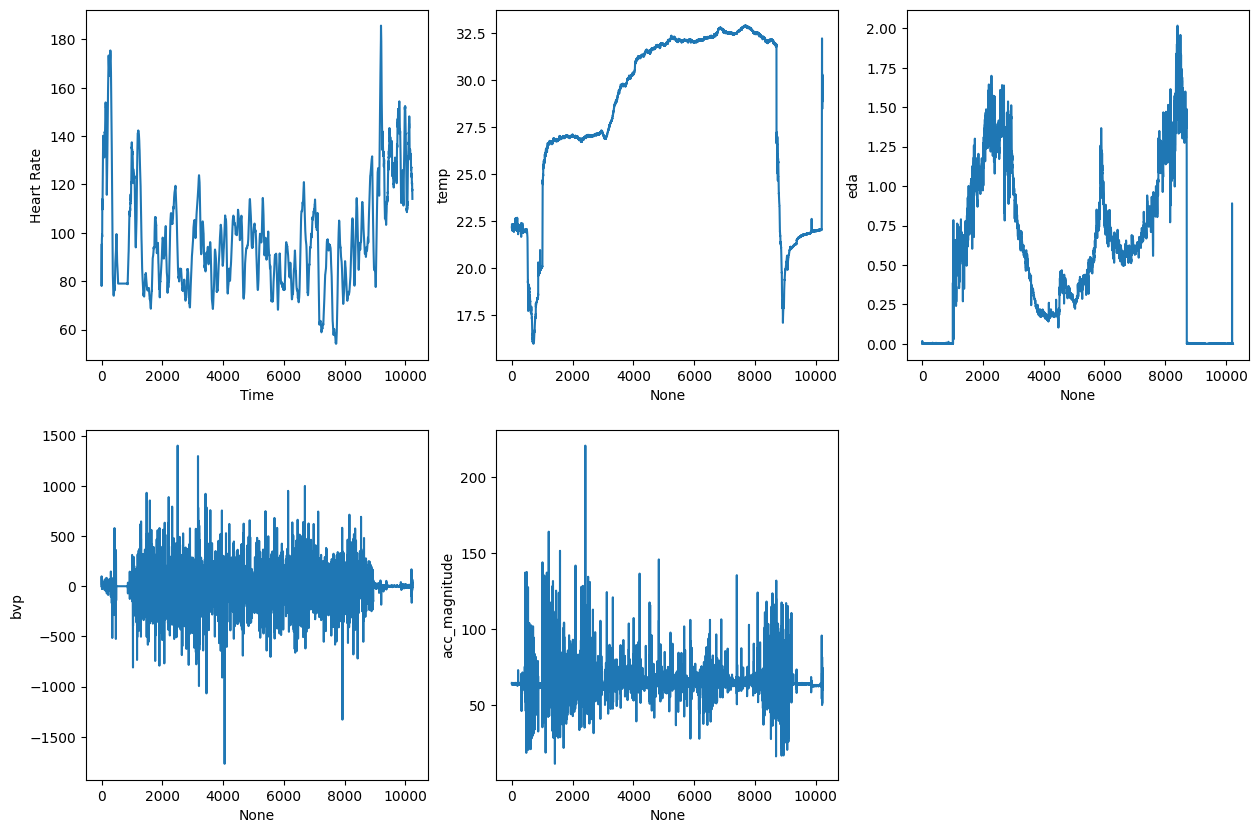

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.lineplot(data = s3_midterm2,
            x = s3_midterm2.index,
            y = 'hr')
plt.xlabel('Time')
plt.ylabel('Heart Rate')


plt.subplot(2, 3, 2)
sns.lineplot(data = s3_midterm2,
            x = s3_midterm2.index,
            y = 'temp')


plt.subplot(2, 3, 3)
sns.lineplot(data = s3_midterm2,
            x = s3_midterm2.index,
            y = 'eda')


plt.subplot(2, 3, 4)
sns.lineplot(data = s3_midterm2,
            x = s3_midterm2.index,
            y = 'bvp')

plt.subplot(2, 3, 5)
sns.lineplot(data = s3_midterm2,
            x = s3_midterm2.index,
            y = 'acc_magnitude')

plt.show()

The graph above show the stress levels for student three during midterm 2. The heart rate graph ranges from 60 to 200 which shows high stress levels during the exam. The temperature graph is similar to the other graphs where it starts low, and then increases, meaning the students temperature suddenly changed during midterm 2. The EDA graph starts low and consistent, with a major jump followed by inconsistency throughout the graph. This indicates stress, anxiety, or nervousness. The BVP graph starts calm and narrow, and then changes significantly, displaying stress. The ACC graph has fluctuations the entire time. This means that the student was moving a lot, or even physically restless during the majority of the exam.

In [ ]:
# repeat for student 2
data_path2 = 'Data/S2'

In [ ]:
final_s2 = data_path2+ '/Final/'
midterm1_s2 = data_path2 + '/Midterm 1/'
midterm2_2 = data_path2 + '/Midterm 2/'

In [ ]:
s2_final_acc= pd.read_csv('/content/drive/MyDrive/Data/S2/Final/ACC.csv')

In [ ]:
s2_final_acc.columns = ['x', 'y', 'z']
s2_final_acc.head()

,x,y,z
0,32.0,32.0,32.0
1,-2.0,-63.0,6.0
2,-2.0,-63.0,6.0
3,-2.0,-63.0,6.0
4,-2.0,-63.0,6.0


In [ ]:
sampling_freq = s2_final_acc.iloc[0].values
acc_s2 = s2_final_acc.iloc[1:].copy().reset_index(drop=True)
acc_s2

,x,y,z
0,-2.0,-63.0,6.0
1,-2.0,-63.0,6.0
2,-2.0,-63.0,6.0
3,-2.0,-63.0,6.0
4,-2.0,-63.0,6.0
...,...,...,...
810775,61.0,-2.0,12.0
810776,65.0,-2.0,10.0
810777,62.0,-8.0,11.0
810778,61.0,-3.0,16.0


In [ ]:
acc_s2['Time'] = np.round(acc_s2.index / sampling_freq[0], 2)
acc_s2

,x,y,z,Time
0,-2.0,-63.0,6.0,0.00
1,-2.0,-63.0,6.0,0.03
2,-2.0,-63.0,6.0,0.06
3,-2.0,-63.0,6.0,0.09
4,-2.0,-63.0,6.0,0.12
...,...,...,...,...
810775,61.0,-2.0,12.0,25336.72
810776,65.0,-2.0,10.0,25336.75
810777,62.0,-8.0,11.0,25336.78
810778,61.0,-3.0,16.0,25336.81


In [ ]:
s2_final_bvp= pd.read_csv('/content/drive/MyDrive/Data/S2/Final/BVP.csv')
s2_final_bvp.columns = ['bvp']
bvp_frequency = s2_final_bvp.iloc[0].values

In [ ]:
bvp_s2 = s2_final_bvp.iloc[1:].copy().reset_index(drop=True)
bvp_s2['Time'] = np.round(bvp_s2.index / bvp_frequency[0], 2)
bvp_s2.head()

,bvp,Time
0,-0.0,0.00
1,-0.0,0.02
2,-0.0,0.03
3,-0.0,0.05
4,-0.0,0.06


In [ ]:
s2_final_eda= pd.read_csv('/content/drive/MyDrive/Data/S2/Final/EDA.csv')

In [ ]:
s2_final_eda.columns = ['eda']
eda_frequency = s2_final_eda.iloc[0].values
eda_s2 = s2_final_eda.iloc[1:].copy().reset_index(drop=True)
eda_s2['Time'] = np.round(eda_s2.index / eda_frequency[0], 2)
eda_s2.head()

,eda,Time
0,0.000000,0.00
1,0.003844,0.25
2,0.015376,0.50
3,0.017939,0.75
4,0.019220,1.00


In [ ]:
s2_final_hr= pd.read_csv('/content/drive/MyDrive/Data/S2/Final/HR.csv')

In [ ]:
s2_final_hr.columns = ['hr']
hr_s2 = s2_final_hr.iloc[1:].copy().reset_index(drop=True)
hr_s2['Time'] = hr_s2.index.values.astype('float')
hr_s2.head()

,hr,Time
0,116.00,0.0
1,82.50,1.0
2,94.67,2.0
3,91.50,3.0
4,88.20,4.0


In [ ]:
s2_final_ibi= pd.read_csv('/content/drive/MyDrive/Data/S2/Final/IBI.csv')
ibi_s2 = s2_final_ibi.copy()
ibi_s2.columns = ['Time', 'ibi']
ibi_s2['Time']= np.round(ibi_s2['Time'].values, 2)
ibi_s2.head()

,Time,ibi
0,77.85,0.437520
1,78.38,0.531274
2,78.82,0.437520
3,79.28,0.468771
4,79.80,0.515649


In [ ]:
s2_final_temp= pd.read_csv('/content/drive/MyDrive/Data/S2/Final/TEMP.csv')


In [ ]:
s2_final_temp.columns = ['temp']
temp_frequency = s2_final_temp.iloc[0].values
temp_s2 = s2_final_temp.iloc[1:].copy().reset_index(drop=True)
temp_s2['Time'] = np.round(temp_s2.index / temp_frequency[0], 2)
temp_s2.head()

,temp,Time
0,22.73,0.00
1,22.73,0.25
2,22.73,0.50
3,22.73,0.75
4,22.73,1.00


In [ ]:
df1 = hr_s2.merge(temp_s2,
                 how = 'inner',
                 on = 'Time')
df2 = df1.merge(eda_s2,
               how = 'inner',
               on = 'Time')
df3 = df2.merge(bvp_s2,
               how = 'inner',
               on = 'Time')
df4 = df3.merge(acc_s2,
               how = 'inner',
               on = 'Time')
df4.head()

,hr,Time,temp,eda,bvp,x,y,z
0,116.00,0.0,22.73,0.000000,-0.00,-2.0,-63.0,6.0
1,82.50,1.0,22.73,0.019220,127.52,-2.0,-63.0,6.0
2,94.67,2.0,22.71,0.019220,-109.11,-2.0,-63.0,6.0
3,91.50,3.0,22.69,0.017939,4.19,-2.0,-63.0,6.0
4,88.20,4.0,22.73,0.020501,-3.65,-2.0,-63.0,6.0


In [ ]:
df4.set_index('Time',  drop = True)

,hr,temp,eda,bvp,x,y,z
Time,,,,,,,
0.0,116.00,22.73,0.000000,-0.00,-2.0,-63.0,6.0
1.0,82.50,22.73,0.019220,127.52,-2.0,-63.0,6.0
2.0,94.67,22.71,0.019220,-109.11,-2.0,-63.0,6.0
3.0,91.50,22.69,0.017939,4.19,-2.0,-63.0,6.0
4.0,88.20,22.73,0.020501,-3.65,-2.0,-63.0,6.0
...,...,...,...,...,...,...,...
25322.0,145.78,24.11,0.016657,-3.57,-1.0,64.0,5.0
25323.0,143.43,23.73,0.016657,-8.69,0.0,63.0,5.0
25324.0,141.10,23.77,0.016657,-7.40,-43.0,40.0,-38.0


In [ ]:

df4['acc_magnitude'] = np.sqrt(df4['x']**2 + df4['y']**2+df4['z']**2)
s2_final = df4.copy()

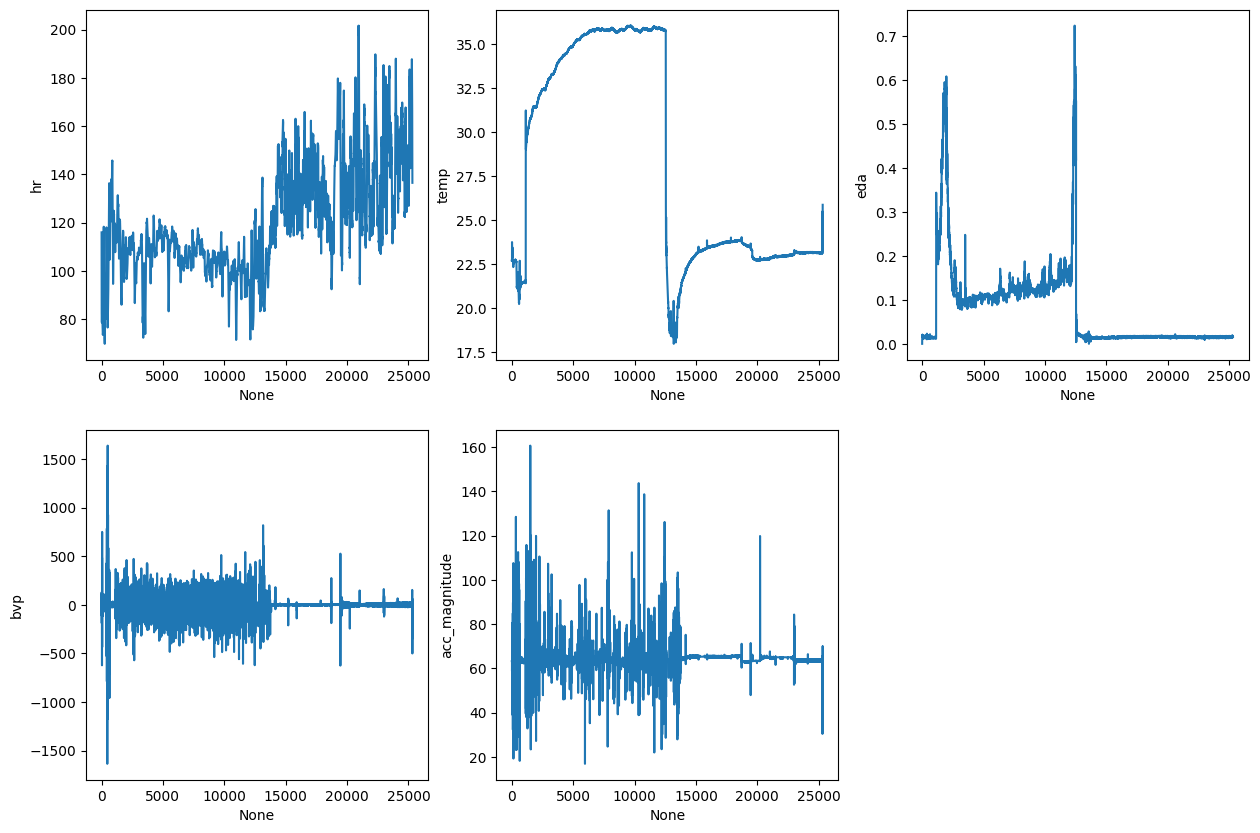

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.lineplot(data = s2_final,
            x = s2_final.index,
            y = 'hr')
plt.subplot(2, 3, 2)
sns.lineplot(data = s2_final,
            x = s2_final.index,
            y = 'temp')

plt.subplot(2, 3, 3)
sns.lineplot(data = s2_final,
            x = s2_final.index,
            y = 'eda')

plt.subplot(2, 3, 4)
sns.lineplot(data = s2_final,
            x = s2_final.index,
            y = 'bvp')
plt.subplot(2, 3, 5)
sns.lineplot(data = s2_final,
            x = s2_final.index,
            y = 'acc_magnitude')

plt.show()

These graphs show how stressed student two was during the final exam. The heart rate graph ranges from 60-190 which shows high stress levels during the exam. The temperature graph is similar to the other graphs where it starts low, and then increases, meaning the students temperature suddenly changed during the final. The EDA graph starts low and consistent, with a major jump followed by inconsistency throughout the graph. This indicates stress, anxiety, or nervousness. The BVP graph starts with a major spike, and then is inconsistent,displaying stress. The ACC graph has fluctuations the entire time. This means that the student was moving a lot, or even physically restless during the majority of the exam.

In [ ]:
s2_midterm1_acc= pd.read_csv('/content/drive/MyDrive/Data/S2/Midterm 1/ACC.csv')

In [ ]:
s2_midterm1_acc.columns = ['x', 'y', 'z']
sampling_freq = s2_midterm1_acc.iloc[0].values
s2_midterm1_acc.head()

,x,y,z
0,32.0,32.0,32.0
1,0.0,-62.0,10.0
2,0.0,-62.0,10.0
3,0.0,-62.0,10.0
4,0.0,-62.0,11.0


In [ ]:
acc_s2_midterm1 = s2_midterm1_acc.iloc[1:].copy().reset_index(drop=True)
acc_s2_midterm1

,x,y,z
0,0.0,-62.0,10.0
1,0.0,-62.0,10.0
2,0.0,-62.0,10.0
3,0.0,-62.0,11.0
4,0.0,-62.0,10.0
...,...,...,...
383491,39.0,2.0,48.0
383492,39.0,2.0,47.0
383493,39.0,2.0,45.0
383494,39.0,1.0,46.0


In [ ]:
s2_midterm1_bvp= pd.read_csv('/content/drive/MyDrive/Data/S2/Midterm 1/BVP.csv')
s2_midterm1_bvp.columns = ['bvp']
bvp_frequency = s2_midterm1_bvp.iloc[0].values

In [ ]:
bvp_s2_midterm1 = s2_midterm1_bvp.iloc[1:].copy().reset_index(drop=True)
bvp_s2_midterm1['Time'] = np.round(bvp_s2_midterm1.index / bvp_frequency[0], 2)
bvp_s2_midterm1.head()

,bvp,Time
0,-0.0,0.00
1,-0.0,0.02
2,-0.0,0.03
3,-0.0,0.05
4,-0.0,0.06


In [ ]:
s2_midterm1_eda= pd.read_csv('/content/drive/MyDrive/Data/S2/Midterm 1/EDA.csv')

In [ ]:
s2_midterm1_eda.columns = ['eda']
eda_frequency = s2_midterm1_eda.iloc[0].values
eda_s2_midterm1 = s2_midterm1_eda.iloc[1:].copy().reset_index(drop=True)
eda_s2_midterm1['Time'] = np.round(eda_s2_midterm1.index / eda_frequency[0], 2)
eda_s2_midterm1.head()

,eda,Time
0,0.000000,0.00
1,0.003844,0.25
2,0.016658,0.50
3,0.017940,0.75
4,0.017940,1.00


In [ ]:
s2_midterm1_hr= pd.read_csv('/content/drive/MyDrive/Data/S2/Midterm 1/HR.csv')

In [ ]:
s2_midterm1_hr.columns = ['hr']
hr_s2_midterm1 = s2_midterm1_hr.iloc[1:].copy().reset_index(drop=True)
hr_s2_midterm1['Time'] = hr_s2_midterm1.index.values.astype('float')
hr_s2_midterm1.head()

,hr,Time
0,85.00,0.0
1,83.50,1.0
2,85.33,2.0
3,87.00,3.0
4,80.00,4.0


In [ ]:
s2_midterm1_ibi= pd.read_csv('/content/drive/MyDrive/Data/S2/Midterm 1/IBI.csv')
ibi_s2_midterm1 = s2_midterm1_ibi.copy()
ibi_s2_midterm1.columns = ['Time', 'ibi']
ibi_s2_midterm1['Time']= np.round(ibi_s2_midterm1['Time'].values, 2)
ibi_s2_midterm1.head()

,Time,ibi
0,68.07,0.359391
1,68.38,0.312514
2,68.71,0.328140
3,169.90,0.437520
4,202.23,0.421894


In [ ]:
s2_midterm1_temp= pd.read_csv('/content/drive/MyDrive/Data/S2/Midterm 1/TEMP.csv')

In [ ]:
s2_midterm1_temp.columns = ['temp']
temp_frequency = s2_midterm1_temp.iloc[0].values
temp_s2_midterm1 = s2_midterm1_temp.iloc[1:].copy().reset_index(drop=True)
temp_s2_midterm1['Time'] = np.round(temp_s2_midterm1.index / temp_frequency[0], 2)
temp_s2_midterm1.head()

,temp,Time
0,22.63,0.00
1,22.63,0.25
2,22.63,0.50
3,22.63,0.75
4,22.63,1.00


In [ ]:
acc_s2_midterm1['Time'] = np.round(acc_s2_midterm1.index / sampling_freq[0], 2)
df1 = hr_s2_midterm1.merge(temp_s2_midterm1,
                 how = 'inner',
                 on = 'Time')

In [ ]:
df2 = df1.merge(eda_s2_midterm1,
               how = 'inner',
               on = 'Time')

In [ ]:
df3 = df2.merge(bvp_s2_midterm1,
                how = 'inner',
                on = 'Time')

In [ ]:
df4 = df3.merge(acc_s2_midterm1,
               how = 'inner',
               on = 'Time')
df4.head()

,hr,Time,temp,eda,bvp,x,y,z
0,85.00,0.0,22.63,0.000000,-0.00,0.0,-62.0,10.0
1,83.50,1.0,22.63,0.017940,117.07,0.0,-62.0,11.0
2,85.33,2.0,22.63,0.019221,8.48,0.0,-62.0,10.0
3,87.00,3.0,22.63,0.016658,5.14,0.0,-62.0,11.0
4,80.00,4.0,22.63,0.017940,1.89,0.0,-63.0,11.0


In [ ]:

s2_midterm1 = df4.copy()
s2_midterm1.set_index('Time',  drop = True)

,hr,temp,eda,bvp,x,y,z
Time,,,,,,,
0.0,85.00,22.63,0.000000,-0.00,0.0,-62.0,10.0
1.0,83.50,22.63,0.017940,117.07,0.0,-62.0,11.0
2.0,85.33,22.63,0.019221,8.48,0.0,-62.0,10.0
3.0,87.00,22.63,0.016658,5.14,0.0,-62.0,11.0
4.0,80.00,22.63,0.017940,1.89,0.0,-63.0,11.0
...,...,...,...,...,...,...,...
11970.0,124.33,24.55,0.014096,-0.03,-2.0,-63.0,7.0
11971.0,123.83,24.53,0.014096,1.87,-2.0,-63.0,8.0
11972.0,123.35,24.53,0.014096,0.17,-2.0,-63.0,8.0


In [ ]:
s2_midterm1['acc_magnitude'] = np.sqrt(df4['x']**2 + df4['y']**2+df4['z']**2)

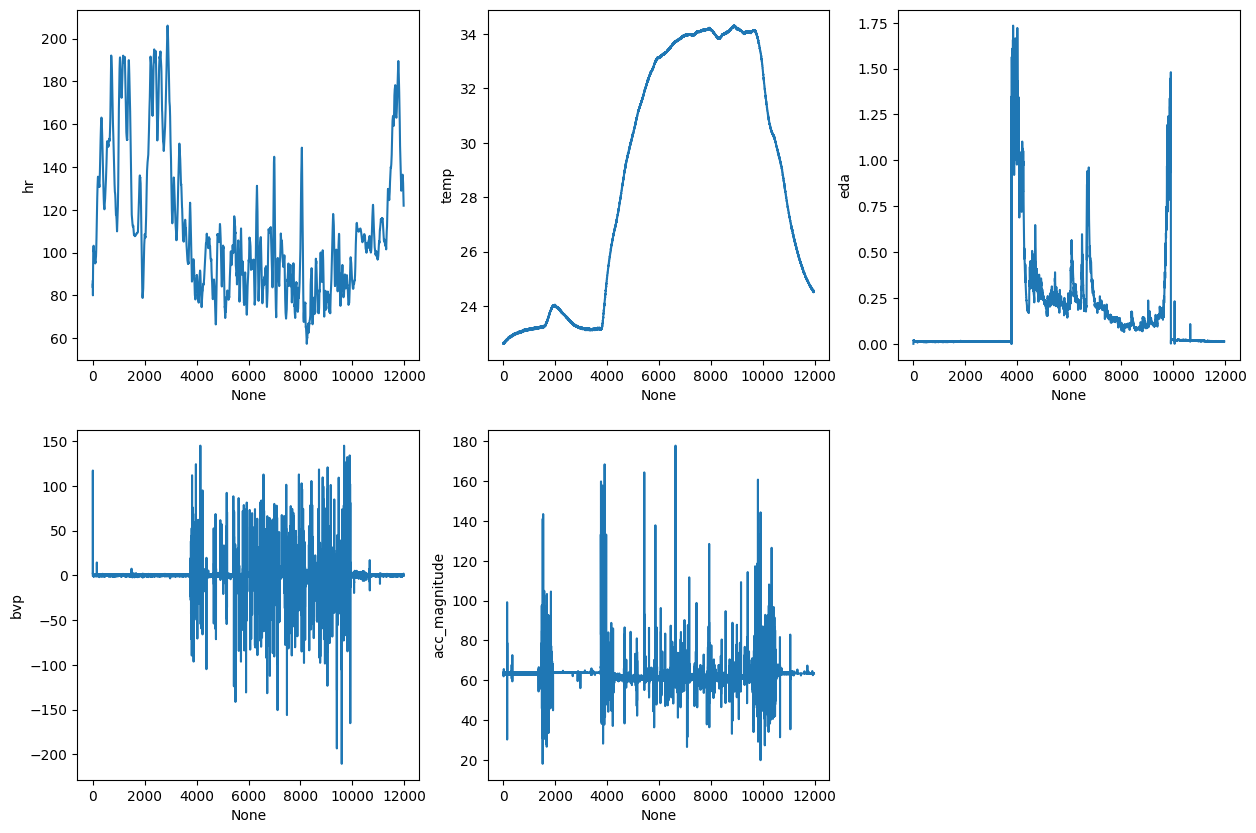

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.lineplot(data = s2_midterm1,
            x = s2_midterm1.index,
            y = 'hr')
plt.subplot(2, 3, 2)
sns.lineplot(data = s2_midterm1,
            x = s2_midterm1.index,
            y = 'temp')

plt.subplot(2, 3, 3)
sns.lineplot(data = s2_midterm1,
            x = s2_midterm1.index,
            y = 'eda')

plt.subplot(2, 3, 4)
sns.lineplot(data = s2_midterm1,
            x = s2_midterm1.index,
            y = 'bvp')
plt.subplot(2, 3, 5)
sns.lineplot(data = s2_midterm1,
            x = s2_midterm1.index,
            y = 'acc_magnitude')

plt.show()

The graph above show the stress levels for student two during midterm 1. The heart rate graph ranges from 60 to 210 which shows high stress levels during the exam. The temperature graph is similar to the other graphs where it starts low, and then increases, meaning the students temperature suddenly changed during midterm 2. The EDA graph starts low and consistent, with a major jump followed by inconsistency throughout the graph. This indicates stress, anxiety, or nervousness. The BVP graph starts with a large spike, and then it flucatues heavily from there on, displaying stress. The ACC graph has fluctuations the entire time. This means that the student was moving a lot, or even physically restless during the majority of the exam.

In [ ]:
s2_midterm2_acc= pd.read_csv('/content/drive/MyDrive/Data/S2/Midterm 2/ACC.csv')

In [ ]:
s2_midterm2_acc.columns = ['x', 'y', 'z']
s2_midterm2_acc.head()

,x,y,z
0,32.0,32.0,32.0
1,-1.0,-63.0,5.0
2,-1.0,-63.0,5.0
3,-1.0,-63.0,5.0
4,-1.0,-63.0,5.0


In [ ]:
sampling_freq = s2_midterm2_acc.iloc[0].values
acc_s2_midterm2 = s2_midterm2_acc.iloc[1:].copy().reset_index(drop=True)
acc_s2_midterm2

,x,y,z
0,-1.0,-63.0,5.0
1,-1.0,-63.0,5.0
2,-1.0,-63.0,5.0
3,-1.0,-63.0,5.0
4,-1.0,-63.0,4.0
...,...,...,...
444313,5.0,-14.0,-63.0
444314,4.0,-12.0,-63.0
444315,2.0,-13.0,-64.0
444316,-2.0,-10.0,-63.0


In [ ]:
acc_s2_midterm2['Time'] = np.round(acc_s2_midterm2.index / sampling_freq[0], 2)

In [ ]:
acc_s2_midterm2

,x,y,z,Time
0,-1.0,-63.0,5.0,0.00
1,-1.0,-63.0,5.0,0.03
2,-1.0,-63.0,5.0,0.06
3,-1.0,-63.0,5.0,0.09
4,-1.0,-63.0,4.0,0.12
...,...,...,...,...
444313,5.0,-14.0,-63.0,13884.78
444314,4.0,-12.0,-63.0,13884.81
444315,2.0,-13.0,-64.0,13884.84
444316,-2.0,-10.0,-63.0,13884.88


In [ ]:
s2_midterm2_bvp= pd.read_csv(midterm2_s2+'/BVP.csv')

In [ ]:
s2_midterm2_bvp.columns = ['bvp']
bvp_frequency = s2_midterm2_bvp.iloc[0].values

In [ ]:
bvp_s2_midterm2 = s2_midterm2_bvp.iloc[1:].copy().reset_index(drop=True)

In [ ]:
bvp_s2_midterm2['Time'] = np.round(bvp_s2_midterm2.index / bvp_frequency[0], 2)

In [ ]:
bvp_s2_midterm2.head()

,bvp,Time
0,-0.0,0.00
1,-0.0,0.02
2,-0.0,0.03
3,-0.0,0.05
4,-0.0,0.06


In [ ]:
s2_midterm2_eda= pd.read_csv(midterm2_s2+'/EDA.csv')

In [ ]:
s2_midterm2_eda.columns = ['eda']
eda_frequency = s2_midterm2_eda.iloc[0].values
eda_s2_midterm2 = s2_midterm2_eda.iloc[1:].copy().reset_index(drop=True)
eda_s2_midterm2['Time'] = np.round(eda_s2_midterm2.index / eda_frequency[0], 2)

In [ ]:
eda_s2_midterm2.head()

,eda,Time
0,0.000000,0.00
1,0.002563,0.25
2,0.015377,0.50
3,0.016658,0.75
4,0.017940,1.00


In [ ]:
s2_midterm2_hr= pd.read_csv(midterm2_s2+'/HR.csv')

In [ ]:
s2_midterm2_hr.columns = ['hr']
hr_s2_midterm2 = s2_midterm2_hr.iloc[1:].copy().reset_index(drop=True)

In [ ]:
hr_s2_midterm2['Time'] = hr_s2_midterm2.index.values.astype('float')

In [ ]:
hr_s2_midterm2.head()

,hr,Time
0,85.00,0.0
1,86.50,1.0
2,88.00,2.0
3,114.75,3.0
4,113.60,4.0


In [ ]:
s2_midterm2_ibi= pd.read_csv(midterm2_s2+'/IBI.csv')

In [ ]:
ibi_s2_midterm2 = s2_midterm2_ibi.copy()
ibi_s2_midterm2.columns = ['Time', 'ibi']

In [ ]:
ibi_s2_midterm2['Time']= np.round(ibi_s2_midterm2['Time'].values, 2)

In [ ]:
ibi_s2_midterm2.head()

,Time,ibi
0,103.63,0.453146
1,104.05,0.421894
2,104.52,0.468771
3,105.02,0.500023
4,121.55,0.468771


In [ ]:
s2_midterm2_temp= pd.read_csv(midterm2_s2+'/TEMP.csv')

In [ ]:
s2_midterm2_temp.columns = ['temp']
temp_frequency = s2_midterm2_temp.iloc[0].values
temp_s2_midterm2 = s2_midterm2_temp.iloc[1:].copy().reset_index(drop=True)
temp_s2_midterm2['Time'] = np.round(temp_s2_midterm2.index / temp_frequency[0], 2)

In [ ]:
temp_s2_midterm2.head()

,temp,Time
0,22.03,0.00
1,22.03,0.25
2,22.03,0.50
3,22.03,0.75
4,22.03,1.00


In [ ]:
df1 = hr_s1.merge(temp_s2_midterm2,
                 how = 'inner',
                 on = 'Time')

In [ ]:
df2 = df1.merge(eda_s2_midterm2,
               how = 'inner',
               on = 'Time')

In [ ]:
df3 = df2.merge(bvp_s2_midterm2,
               how = 'inner',
               on = 'Time')

In [ ]:
df4 = df3.merge(acc_s2_midterm2,
               how = 'inner',
               on = 'Time')

In [ ]:
df4.set_index('Time', drop = True)

,hr,temp,eda,bvp,x,y,z
Time,,,,,,,
0.0,116.00,22.03,0.000000,-0.00,-1.0,-63.0,5.0
1.0,82.50,22.03,0.017940,113.53,-1.0,-63.0,5.0
2.0,96.33,22.03,0.016658,21.93,-1.0,-63.0,5.0
3.0,86.25,22.05,0.017940,2.01,-1.0,-63.0,5.0
4.0,98.60,22.09,0.017940,19.25,-1.0,-63.0,4.0
...,...,...,...,...,...,...,...
13879.0,106.57,25.01,0.014096,-0.52,-19.0,59.0,-9.0
13880.0,107.78,24.95,0.015377,-2.52,1.0,53.0,-38.0
13881.0,108.98,24.95,0.014096,-1.10,-6.0,-4.0,-56.0


In [ ]:
df4['acc_magnitude'] = np.sqrt(df4['x']**2 + df4['y']**2+df4['z']**2)

In [ ]:
s2_midterm2 = df4.copy()

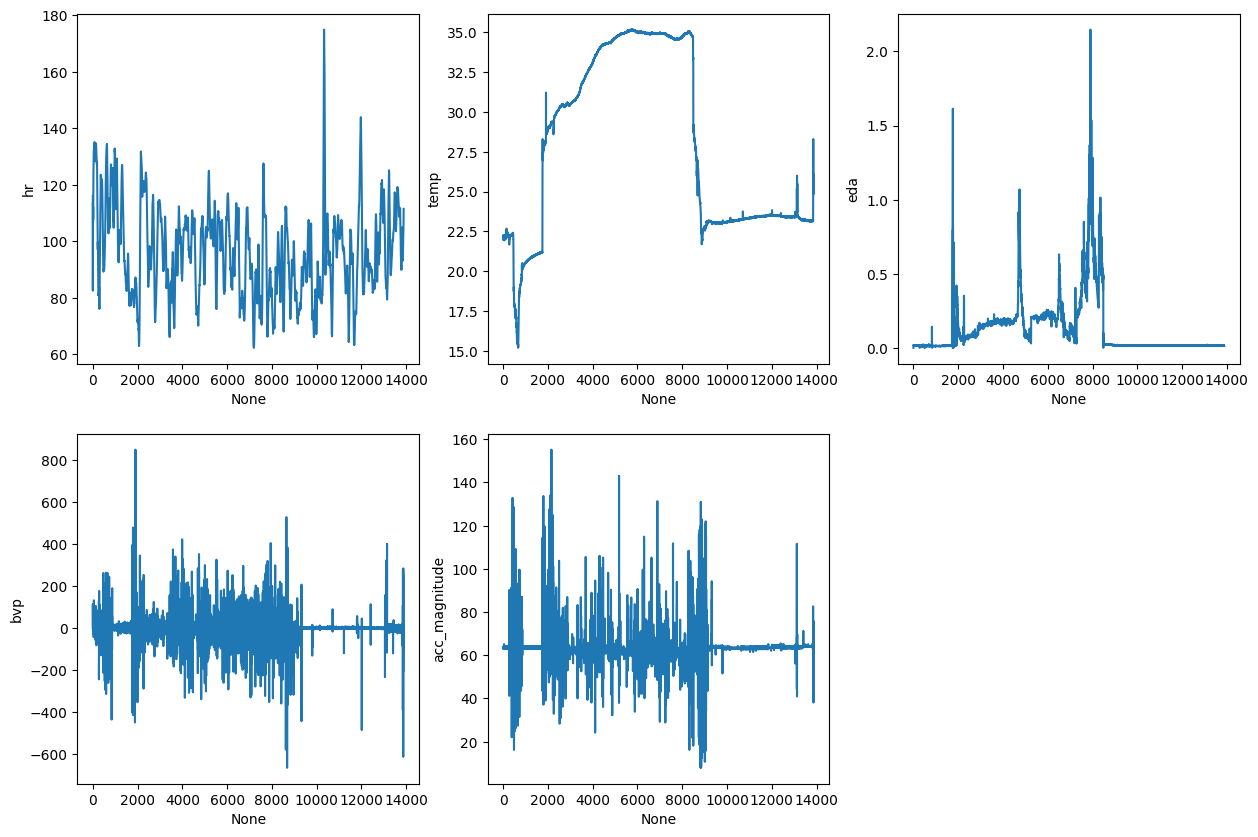

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.lineplot(data = s2_midterm2,
            x = s2_midterm2.index,
            y = 'hr')
plt.subplot(2, 3, 2)
sns.lineplot(data = s2_midterm2,
            x = s2_midterm2.index,
            y = 'temp')

plt.subplot(2, 3, 3)
sns.lineplot(data = s2_midterm2,
            x = s2_midterm2.index,
            y = 'eda')

plt.subplot(2, 3, 4)
sns.lineplot(data = s2_midterm2,
            x = s2_midterm2.index,
            y = 'bvp')
plt.subplot(2, 3, 5)
sns.lineplot(data = s2_midterm2,
            x = s2_midterm2.index,
            y = 'acc_magnitude')

plt.show()

The graph above show the stress levels for student two during midterm 2. The heart rate graph ranges from 60 to 175 which shows high stress levels during the exam. The temperature graph is similar to the other graphs where it starts low, and then increases, meaning the students temperature suddenly changed during midterm 2. The EDA graph starts low and consistent, with a major jump followed by inconsistency throughout the graph. This indicates stress, anxiety, or nervousness. The BVP graph starts out inconsistent, with major spikes throughout.The ACC graph has fluctuations the entire time. This means that the student was moving a lot, or even physically restless during the majority of the exam.

In [ ]:
# create dictionary for grades
s1_grades = dict(zip(['Midterm 1', 'Midterm 2', 'Final'], [78, 82, 91]))
s2_grades = dict(zip(['Midterm 1', 'Midterm 2', 'Final'], [82, 85, 90]))
s3_grades = dict(zip(['Midterm 1', 'Midterm 2', 'Final'], [77, 90, 94]))

In [ ]:
## Create a composite stress index using EDA, HR and ACC magnitude.

def calculate_stress_index(df):
    # 1. Normalize (0-1)
    df['eda_n'] = (df['eda'] - df['eda'].min()) / (df['eda'].max() - df['eda'].min())
    df['hr_n'] = (df['hr'] - df['hr'].min()) / (df['hr'].max() - df['hr'].min())
    df['acc_n'] = (df['acc_magnitude'] - df['acc_magnitude'].min()) / (df['acc_magnitude'].max() - df['acc_magnitude'].min())

    # 2. Combine with Motion Filter
    # If movement is high (>0.3), we dampen the stress score
    raw_score = (0.6 * df['eda_n']) + (0.4 * df['hr_n'])
    df['stress_score'] = raw_score * (1 - df['acc_n'])
    return df

# Apply to each student/exam dataframe
processed_df_s1 = calculate_stress_index(s1_final)


keep = ['Time', 'eda_n', 'hr_n', 'acc_n']
processed_df_s1= processed_df_s1[keep]

processed_df_s1

,Time,eda_n,hr_n,acc_n
0,0.0,0.000000,0.477214,0.299053
1,1.0,0.061856,0.179622,0.299053
2,2.0,0.061856,0.302478,0.299053
3,3.0,0.061856,0.212934,0.299053
4,4.0,0.058420,0.322644,0.299053
...,...,...,...,...
23382,23382.0,0.068730,0.540730,0.337435
23383,23383.0,0.068730,0.536999,0.249670
23384,23384.0,0.068730,0.534068,0.272912
23385,23385.0,0.072165,0.530070,0.269996


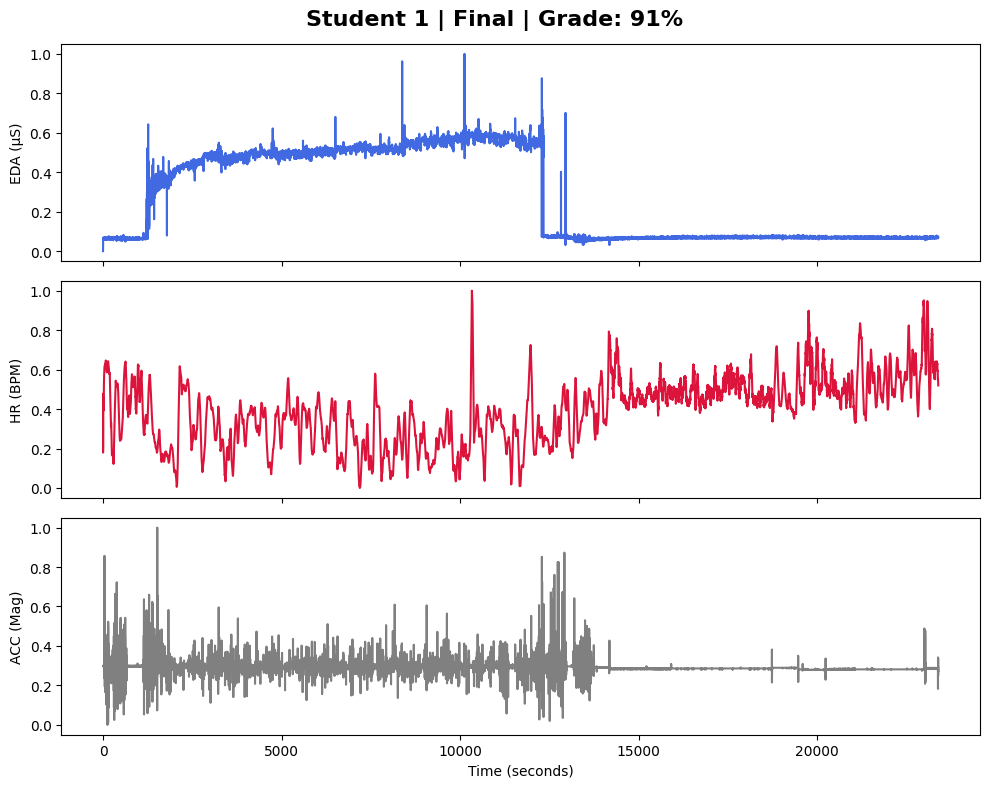

In [ ]:

student_id = "Student 1"
exam_id = "Final"
grade = s1_grades['Final']


# 2. Create 3 stacked subplots (Share X-axis to see correlations)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# 3. Plot the three variables
sns.lineplot(data=processed_df_s1, x='Time', y='eda_n', ax=ax1, color='royalblue')
ax1.set_ylabel('EDA (μS)')

sns.lineplot(data=processed_df_s1, x='Time', y='hr_n', ax=ax2, color='crimson')
ax2.set_ylabel('HR (BPM)')

sns.lineplot(data=processed_df_s1, x='Time', y='acc_n', ax=ax3, color='gray')
ax3.set_ylabel('ACC (Mag)')

# 4.showing the grade: Title
plt.suptitle(f"{student_id} | {exam_id} | Grade: {grade}%", fontsize=16, fontweight='bold')
plt.xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

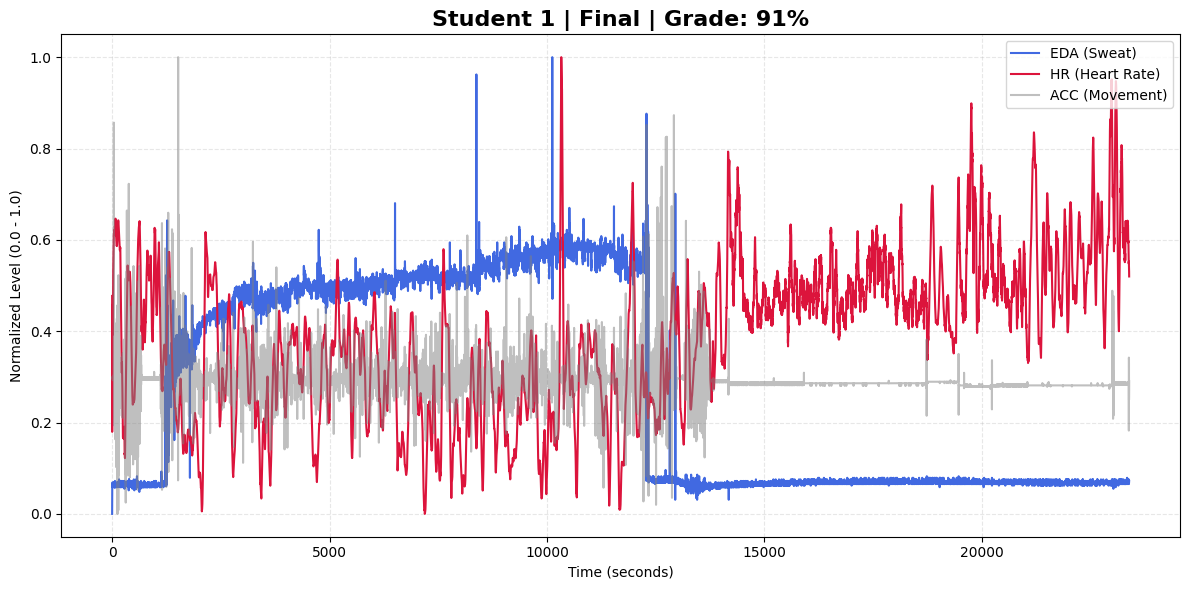

In [ ]:
plt.figure(figsize=(12, 6))

# 2. Plot all three variables on the same axis
sns.lineplot(data=processed_df_s1, x='Time', y='eda_n', color='royalblue', label='EDA (Sweat)')
sns.lineplot(data=processed_df_s1, x='Time', y='hr_n', color='crimson', label='HR (Heart Rate)')
sns.lineplot(data=processed_df_s1, x='Time', y='acc_n', color='gray', alpha=0.5, label='ACC (Movement)')

# 3. Add the Grade and Labels
plt.title(f"{student_id} | {exam_id} | Grade: {grade}%", fontsize=16, fontweight='bold')
plt.ylabel("Normalized Level (0.0 - 1.0)")
plt.xlabel("Time (seconds)")

# 4. Clean up the legend and layout
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

/tmp/ipykernel_13210/3103928090.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['composite_stress'] = raw_stress * (1 - df['acc_n'])


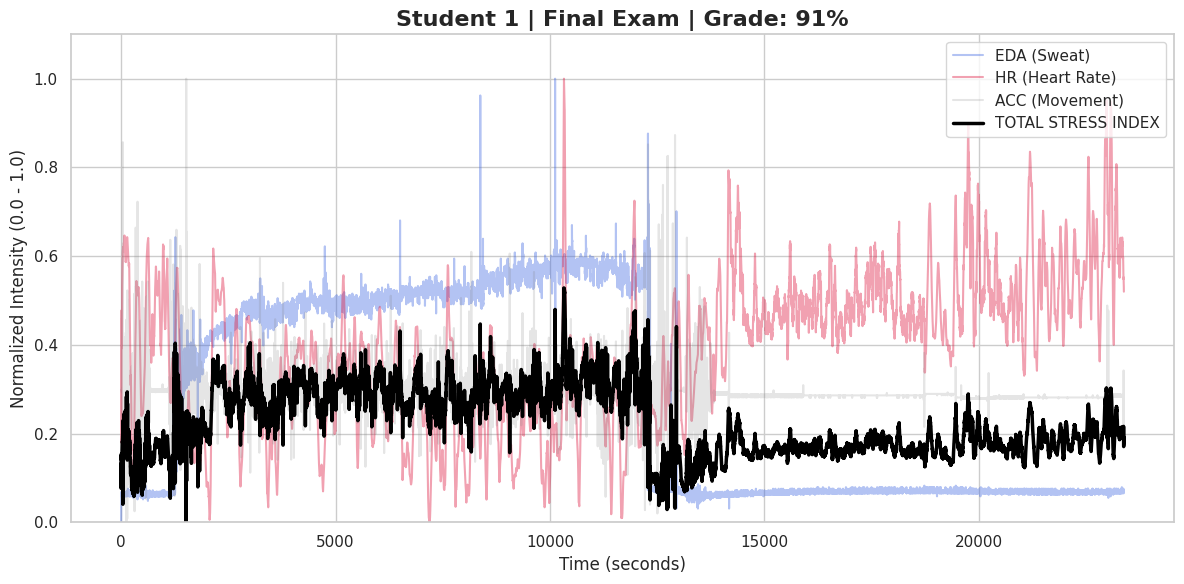

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: Define your Specific Session ---
student_id = "Student 1"
exam_id = "Final"
grade = s1_grades['Final'] # Calling the value from your dictionary
df = processed_df_s1       # Your specific student dataframe

# --- STEP 2: Calculate the Composite Stress Score ---
# Formula: (60% EDA + 40% HR) then dampened by ACC (Movement)
# This ensures that "fidgeting" doesn't look like "mental stress"
raw_stress = (0.6 * df['eda_n']) + (0.4 * df['hr_n'])
df['composite_stress'] = raw_stress * (1 - df['acc_n'])

# --- STEP 3: Create the Single Overlay Plot ---
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot the 3 Raw Variables (Normalized)
sns.lineplot(data=df, x='Time', y='eda_n', color='royalblue', label='EDA (Sweat)', alpha=0.4)
sns.lineplot(data=df, x='Time', y='hr_n', color='crimson', label='HR (Heart Rate)', alpha=0.4)
sns.lineplot(data=df, x='Time', y='acc_n', color='gray', label='ACC (Movement)', alpha=0.2)

# Plot the NEW Composite Stress Score (Bold & Solid)
sns.lineplot(data=df, x='Time', y='composite_stress', color='black', linewidth=2.5, label='TOTAL STRESS INDEX')

# --- STEP 4: Annotate with the Grade ---
plt.title(f"{student_id} | {exam_id} Exam | Grade: {grade}%", fontsize=16, fontweight='bold')
plt.ylabel("Normalized Intensity (0.0 - 1.0)")
plt.xlabel("Time (seconds)")
plt.ylim(0, 1.1) # Gives a little head-room for the legend
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

During the final Exam, student 1 is stressed but much more stable in comparison to midterms 1 and 2. The activity/arousal builds slowly and remains much more controlled than in previous exams. The peak and variation is much lower, which shows the student was much less erratic suggesting they had more focus and less emotional volatility. Student 1 recieved their highest grade on this exam.

/tmp/ipykernel_13210/3647523365.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['composite_stress'] = raw_stress * (1 - df['acc_n'])


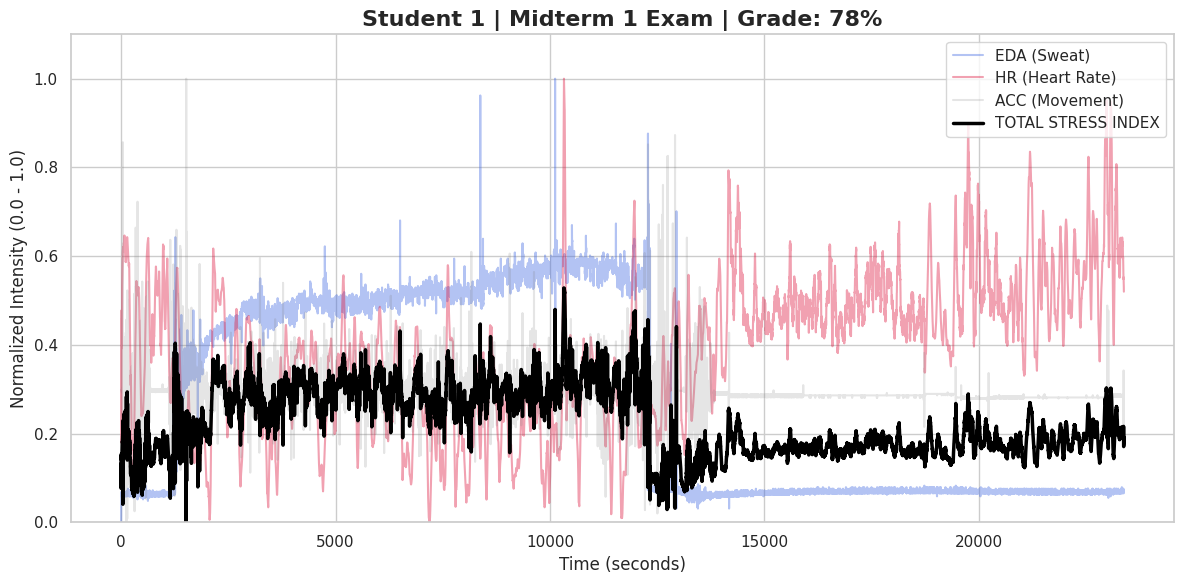

In [ ]:
# --- STEP 1: Define your Specific Session ---
student_id = "Student 1"
exam_id = "Midterm 1"
grade = s1_grades['Midterm 1'] # Calling the value from your dictionary
df = processed_df_s1       # Your specific student dataframe

# --- STEP 2: Calculate the Composite Stress Score ---
# Formula: (60% EDA + 40% HR) then dampened by ACC (Movement)
# This ensures that "fidgeting" doesn't look like "mental stress"
raw_stress = (0.6 * df['eda_n']) + (0.4 * df['hr_n'])
df['composite_stress'] = raw_stress * (1 - df['acc_n'])

# --- STEP 3: Create the Single Overlay Plot ---
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot the 3 Raw Variables (Normalized)
sns.lineplot(data=df, x='Time', y='eda_n', color='royalblue', label='EDA (Sweat)', alpha=0.4)
sns.lineplot(data=df, x='Time', y='hr_n', color='crimson', label='HR (Heart Rate)', alpha=0.4)
sns.lineplot(data=df, x='Time', y='acc_n', color='gray', label='ACC (Movement)', alpha=0.2)

# Plot the NEW Composite Stress Score (Bold & Solid)
sns.lineplot(data=df, x='Time', y='composite_stress', color='black', linewidth=2.5, label='TOTAL STRESS INDEX')

# --- STEP 4: Annotate with the Grade ---
plt.title(f"{student_id} | {exam_id} Exam | Grade: {grade}%", fontsize=16, fontweight='bold')
plt.ylabel("Normalized Intensity (0.0 - 1.0)")
plt.xlabel("Time (seconds)")
plt.ylim(0, 1.1) # Gives a little head-room for the legend
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

Student 1 experiences a big spike in EDA and overall stress that reaches its peack for the exam. This state indicates high arousal, suggesting the student had intense mental effort or high stress. Additionally, the student's movement remained low during the spikes and variations, so we can assume that the stress and arousal was purely caused by mental stress rather than physical movement.They also performed the poorest on the exam.

/tmp/ipykernel_13210/2285869020.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['composite_stress'] = raw_stress * (1 - df['acc_n'])


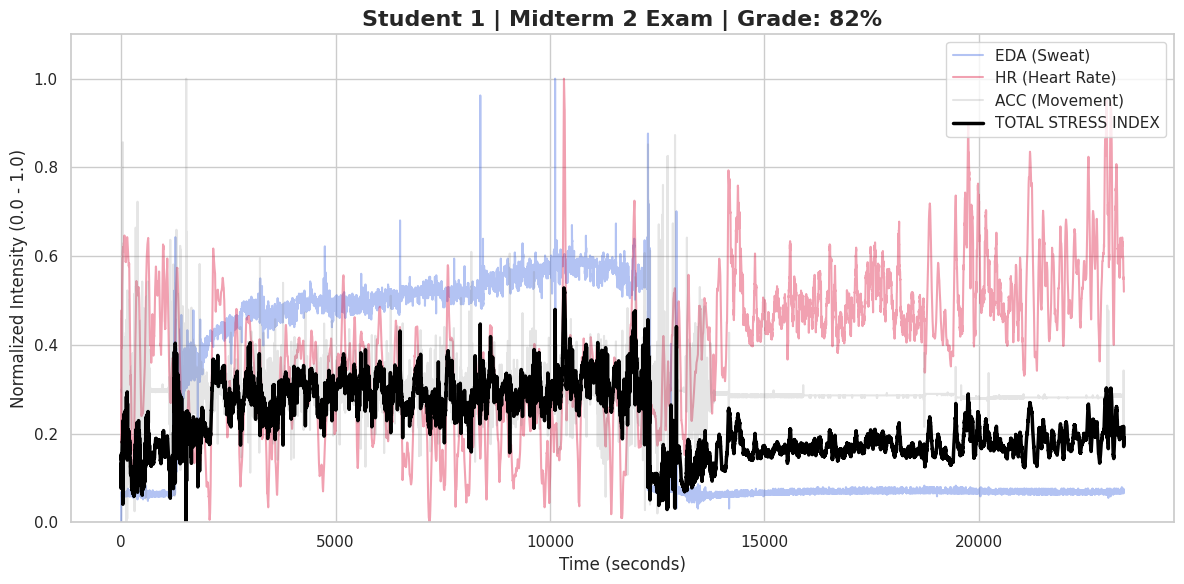

In [ ]:
student_id = "Student 1"
exam_id = "Midterm 2"
grade = s1_grades['Midterm 2'] # Calling the value from your dictionary
df = processed_df_s1       # Your specific student dataframe

# --- STEP 2: Calculate the Composite Stress Score ---
# Formula: (60% EDA + 40% HR) then dampened by ACC (Movement)
# This ensures that "fidgeting" doesn't look like "mental stress"
raw_stress = (0.6 * df['eda_n']) + (0.4 * df['hr_n'])
df['composite_stress'] = raw_stress * (1 - df['acc_n'])

# --- STEP 3: Create the Single Overlay Plot ---
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot the 3 Raw Variables (Normalized)
sns.lineplot(data=df, x='Time', y='eda_n', color='royalblue', label='EDA (Sweat)', alpha=0.4)
sns.lineplot(data=df, x='Time', y='hr_n', color='crimson', label='HR (Heart Rate)', alpha=0.4)
sns.lineplot(data=df, x='Time', y='acc_n', color='gray', label='ACC (Movement)', alpha=0.2)

# Plot the NEW Composite Stress Score (Bold & Solid)
sns.lineplot(data=df, x='Time', y='composite_stress', color='black', linewidth=2.5, label='TOTAL STRESS INDEX')

# --- STEP 4: Annotate with the Grade ---
plt.title(f"{student_id} | {exam_id} Exam | Grade: {grade}%", fontsize=16, fontweight='bold')
plt.ylabel("Normalized Intensity (0.0 - 1.0)")
plt.xlabel("Time (seconds)")
plt.ylim(0, 1.1) # Gives a little head-room for the legend
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

The student still experiences a sharp rise in EDA that occurs a little earlier in the exam. The way the student recovers and the overall stress volume has decreased since midterm 1. The student scored higher on this exam than the first. They sustained more rather than having sharp and sudden peaks.

**Summary:**
Through this project, many things have been learned regarding how stress can affect students academically. For this project, several graphs were made showing how the three students' heart rate, temperature, EDA (electrodermal activity), BVP (blood vessel prosthesis), and ACC magnitude, or the movement of an individual, were affected by stress. All three of the students we examined took the midterm 1, midterm 2, and the final exam. We had three research questions which included: How do stress-related biometric signals change across three exams? Do students with higher physiological stress patterns tend to have lower grades? Which measure appears to vary the most during the exams? Through this research, we were able to answer all three of those questions. Throughout the three exams it was common for all three students to have an unsteady heartrate, ranging from as low as 60 beats to as high as 210 beats during the exam. It was also common for the students to be moving around, as the ACC graphs were always fluctuating. This made sense as the students had a wrist monitor around their arm to observe any changes to their body while taking the exam. EDA is involved with the electrical characteristics of the skin, so if the students were stressed out, the EDA would pick up on that, resulting in graphs that fluctuated heavily. Through this research, we discovered that students do not have lower grades based on physiological stress patterns. Although the students seemed to be stressed during the three exams, the grades were not lower like we originally believed in our hypothesis. Second, the stress-related biometric signals did fluctuate heavily as the graphs showed, however all three students had similar fluctuations, including their heart rate, and EDA. Third, the measure that appeared the most during the three exams was heart rate. Although there were many variables in this dataset, we learned that heartrate, EDA, and ACC were the most important because they are directly related to someone’s stress levels.
This project helped us see that not only is stress just emotional, it can also be observed through the body’s physical responses. Our project can provide value to society because stress is very common for students, workers, and many other people in high-pressure environments. By understanding how stress is measured and how it changes, can help schools, universities, and the workplace will be able to do a better job at providing mental health support. Our project could also help a business because if stress can be measured through bio-metric signals as it is in this experiment, businesses may be able to understand further how stress affects employee productivity, concentration, and well-being. This can overall help their business because business leaders will be able to help their employees, because they understand how stress can be measured and potential causes. The next steps for this project could be to include more students so that way the results are more reliable. We could also research not only stress during exams, but how the time of day of taking exams, sleep quality, substance abuse, and other issues that affect mental health, to see how stress is affected overall. We would use a similar process by using graphs to show our findings, as it shows a clear and comprehensive view of our research.
Ethical considerations of this project would be the privacy and confidentiality. Biometric data is personal and sensitive information from a person’s body, so it’s crucial to keep that information private, as the test group might not want that information to be exposed. Consent is also important. The participants should know what data is being collected, why it’s being collected, and the participants should be voluntary. Finally, we should avoid harm or misuse. An example of this would be labeling a student who has a high rate as a student who “does bad under pressure.” It is important to not misinterpret data, and make unfair assumptions about the participants, because that is morally and ethically wrong. Therefore, it’s important to remain mindful during this project because it’s important to be thoughtful of others (no misuse or harm), respectful (consent), and responsible (keeping the privacy and confidentiality).
